In [1050]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from dotenv import load_dotenv
import os
import requests
import json
import numpy as np

In [1051]:
load_dotenv()

True

## Collecting historical financial news 

This is the **End-Of-Day Historical Stock Market Data API** from [fin historical data](https://eodhd.com/financial-apis/api-for-historical-data-and-volumes)


```
With End-of-Day data API, we have data for more than 150 000 tickers all around the world. We cover all US stocks, ETFs, and Mutual Funds (more than 51 000 in total) from the beginning, for example, the Ford Motors data is from Jun 1972 and so on. And non-US stock exchanges we cover mostly from Jan 3, 2000. We do provide daily, weekly and monthly data raw and adjusted to splits and dividends.

Note. Free plan gives access to 1 year of historical depth for EOD data only.
```


## Notes so far

1. volume appears seasonal

2. open, high, close, adjusted close are highly correlated


In [1052]:
fin_historical = os.getenv("fin_historical_data")

In [1053]:
previous_historical_data = pd.read_csv("../financial_data/17_04_2026_us.csv")
previous_historical_data['date'] = pd.to_datetime(previous_historical_data['date'])

In [1054]:
previous_historical_data.head()

,date,open,high,low,close,adjusted_close,volume
0,2025-04-21,311.00,311.28,305.12,308.72,301.7516,2669900
1,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
2,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
3,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
4,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900


In [1055]:
historical_data = requests.get(f"https://eodhd.com/api/eod/MCD.US?api_token={fin_historical}&fmt=json")

In [1056]:
historical_data

<Response [200]>

In [1057]:
df = pd.json_normalize(historical_data.json())

In [1058]:
df['date'] = pd.to_datetime(df['date'])

In [1059]:
df

,date,open,high,low,close,adjusted_close,volume
0,2025-04-28,317.70,318.02,314.25,316.81,309.6590,2578300
1,2025-04-29,316.06,316.73,313.00,314.50,307.4012,3164500
2,2025-04-30,316.79,321.00,313.10,319.65,312.4349,5564600
3,2025-05-01,313.15,319.25,311.60,313.64,306.5606,5186900
4,2025-05-02,313.55,315.97,310.68,311.96,304.9185,3994600
...,...,...,...,...,...,...,...
245,2026-04-20,312.15,312.53,305.95,306.94,306.9400,2395200
246,2026-04-21,305.55,306.15,300.97,301.84,301.8400,2708100
247,2026-04-22,302.05,302.91,299.83,300.07,300.0700,2845600
248,2026-04-23,302.50,304.89,301.92,302.53,302.5300,3064300


In [1060]:
# combining the datasets


df = pd.concat([previous_historical_data, df], axis=0) 






In [1061]:
df.head()

,date,open,high,low,close,adjusted_close,volume
0,2025-04-21,311.00,311.28,305.12,308.72,301.7516,2669900
1,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
2,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
3,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
4,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900


In [1062]:
df.duplicated().sum()

244

In [1063]:
df.index = pd.to_datetime(df['date'])
df['date'] = pd.to_datetime(df['date'])

In [1064]:
df

,date,open,high,low,close,adjusted_close,volume
date,,,,,,,
2025-04-21,2025-04-21,311.00,311.28,305.12,308.72,301.7516,2669900
2025-04-22,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
2025-04-23,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
2025-04-24,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
2025-04-25,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900
...,...,...,...,...,...,...,...
2026-04-20,2026-04-20,312.15,312.53,305.95,306.94,306.9400,2395200
2026-04-21,2026-04-21,305.55,306.15,300.97,301.84,301.8400,2708100
2026-04-22,2026-04-22,302.05,302.91,299.83,300.07,300.0700,2845600


In [1065]:
df.duplicated().sum()

244

In [1066]:
df.drop_duplicates(inplace=True) 

df

,date,open,high,low,close,adjusted_close,volume
date,,,,,,,
2025-04-21,2025-04-21,311.00,311.28,305.12,308.72,301.7516,2669900
2025-04-22,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
2025-04-23,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
2025-04-24,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
2025-04-25,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900
...,...,...,...,...,...,...,...
2026-04-20,2026-04-20,312.15,312.53,305.95,306.94,306.9400,2395200
2026-04-21,2026-04-21,305.55,306.15,300.97,301.84,301.8400,2708100
2026-04-22,2026-04-22,302.05,302.91,299.83,300.07,300.0700,2845600


<Axes: ylabel='Frequency'>

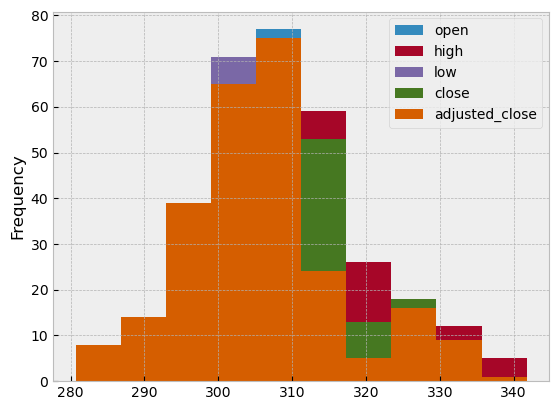

In [1067]:
df[['open', 'high', 'low', 'close', 'adjusted_close']].plot(kind='hist')

In [1068]:
df

,date,open,high,low,close,adjusted_close,volume
date,,,,,,,
2025-04-21,2025-04-21,311.00,311.28,305.12,308.72,301.7516,2669900
2025-04-22,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
2025-04-23,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
2025-04-24,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
2025-04-25,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900
...,...,...,...,...,...,...,...
2026-04-20,2026-04-20,312.15,312.53,305.95,306.94,306.9400,2395200
2026-04-21,2026-04-21,305.55,306.15,300.97,301.84,301.8400,2708100
2026-04-22,2026-04-22,302.05,302.91,299.83,300.07,300.0700,2845600


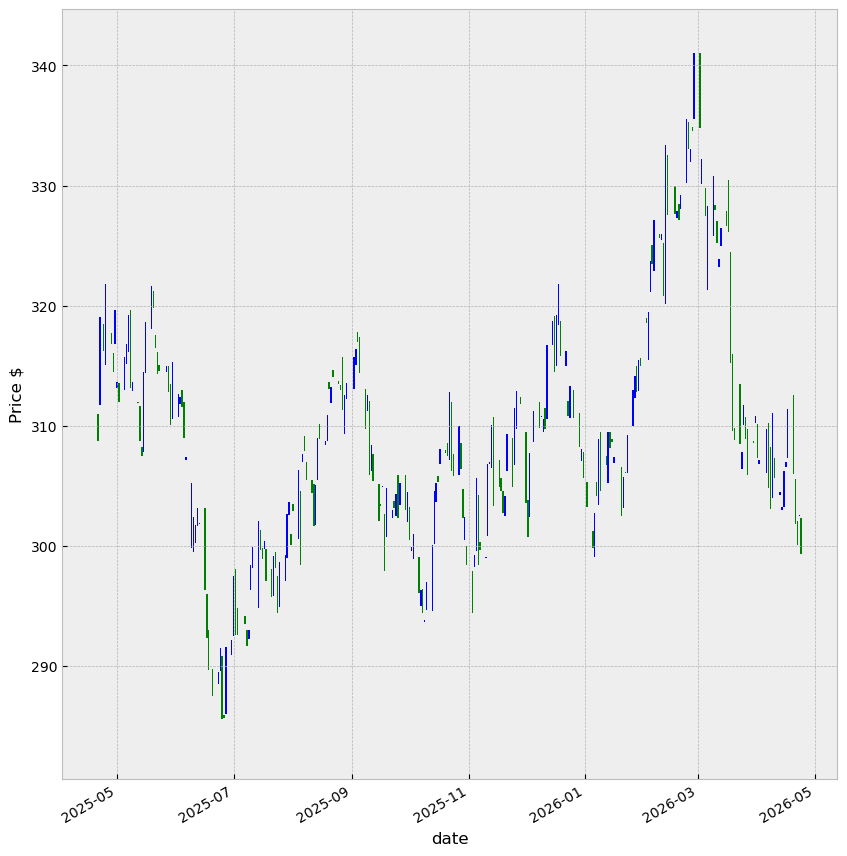

In [1069]:
plt.figure(figsize=(10,10))
stock_prices=df
# "up" dataframe will store the stock_prices 
# when the closing stock price is greater
# than or equal to the opening stock prices
up = stock_prices[stock_prices.close >= stock_prices.open]

# "down" dataframe will store the stock_prices
# when the closing stock price is
# lesser than the opening stock prices
down = stock_prices[stock_prices.close < stock_prices.open]

# When the stock prices have decreased, then it
# will be represented by blue color candlestick
col1 = 'blue'

# When the stock prices have increased, then it 
# will be represented by green color candlestick
col2 = 'green'

# Setting width of candlestick elements
width = .7
width2 = .09

# Plotting up prices of the stock
plt.bar(up.index, up.close-up.open, width, bottom=up.open, color=col1)
plt.bar(up.index, up.high-up.close, width2, bottom=up.close, color=col1)
plt.bar(up.index, up.low-up.open, width2, bottom=up.open, color=col1)

# Plotting down prices of the stock
plt.bar(down.index, down.close-down.open, width, bottom=down.open, color=col2)
plt.bar(down.index, down.high-down.open, width2, bottom=down.open, color=col2)
plt.bar(down.index, down.low-down.close, width2, bottom=down.close, color=col2)

# rotating the x-axis tick labels at 30degree 
# towards right
plt.xticks(rotation=30, ha='right')

# displaying candlestick chart of stock data 
# of a week
plt.xlabel("date") 
plt.ylabel("Price $")
plt.show()

In [1070]:
df.corr(numeric_only=True)

,open,high,low,close,adjusted_close,volume
open,1.000000,0.982742,0.982491,0.962635,0.949078,-0.175754
high,0.982742,1.000000,0.986093,0.985485,0.969497,-0.125269
low,0.982491,0.986093,1.000000,0.983313,0.967516,-0.203218
close,0.962635,0.985485,0.983313,1.000000,0.980099,-0.142294
adjusted_close,0.949078,0.969497,0.967516,0.980099,1.000000,-0.142906
volume,-0.175754,-0.125269,-0.203218,-0.142294,-0.142906,1.000000


<Axes: xlabel='date'>

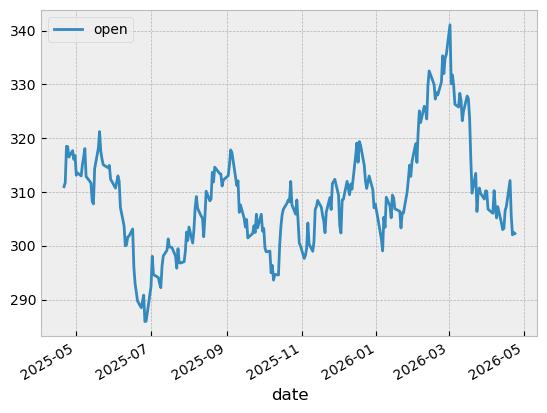

In [1071]:
df.plot(kind='line', x='date', y='open')

<Axes: xlabel='date'>

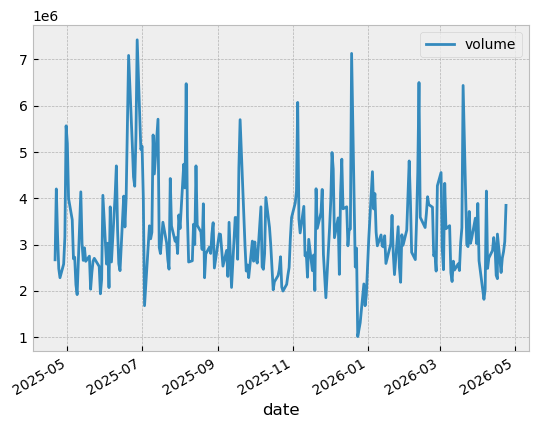

In [1072]:
df.plot(kind='line', x='date', y='volume')

In [1073]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [1074]:
series = df['volume']
result = seasonal_decompose(series, model='additive', period=12)

In [1075]:
result

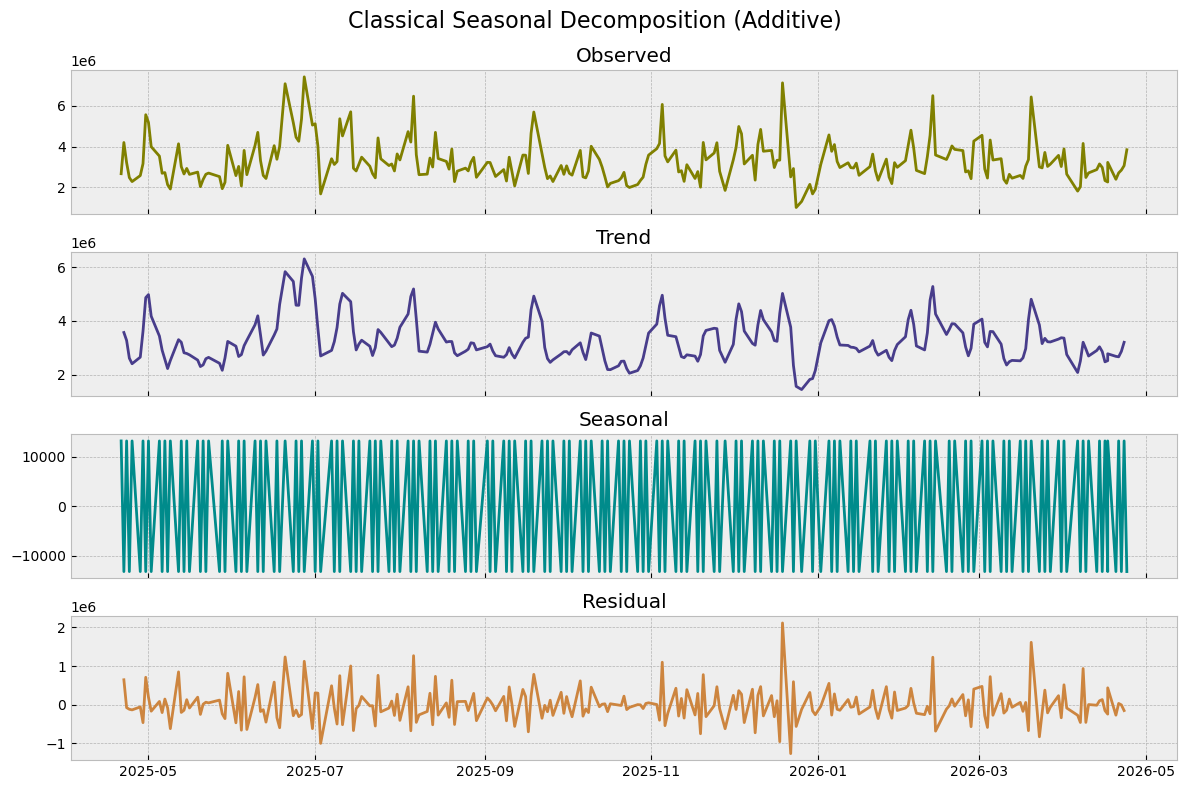

In [1076]:
series = df['volume']
result = seasonal_decompose(series, model='additive', period=2)

fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

axs[0].plot(result.observed, color='olive')
axs[0].set_title('Observed')

axs[1].plot(result.trend, color='darkslateblue')
axs[1].set_title('Trend')

axs[2].plot(result.seasonal, color='darkcyan')
axs[2].set_title('Seasonal')

axs[3].plot(result.resid, color='peru')
axs[3].set_title('Residual')

plt.suptitle('Classical Seasonal Decomposition (Additive)', fontsize=16)
plt.tight_layout()
plt.show()

In [1077]:
# using a statistical test for volume
from scipy.stats import kruskal

# Detecting anomalies

since i only have a year's worth of data, I will need to use more simple methods

In [1078]:
open = df['open']

In [1079]:
# method 1 - using standard deviation

rolling_deviations = pd.Series(dtype=float, index=open.index)
for date in rolling_deviations.index:
    window = open.loc[:date]
    rolling_deviations.loc[date]=window.std() 

    

In [1080]:
rolling_deviations

date
2025-04-21         NaN
2025-04-22    0.537401
2025-04-23    4.128260
2025-04-24    4.102376
2025-04-25    3.622129
                ...   
2026-04-20    9.905822
2026-04-21    9.888762
2026-04-22    9.879255
2026-04-23    9.868510
2026-04-24    9.858328
Length: 256, dtype: float64

In [1081]:
diff_rolling_deviations = rolling_deviations.diff() 
diff_rolling_deviations=diff_rolling_deviations.dropna()

In [1082]:
diff_rolling_deviations

date
2025-04-23    3.590859
2025-04-24   -0.025884
2025-04-25   -0.480247
2025-04-28   -0.230065
2025-04-29   -0.291641
                ...   
2026-04-20   -0.017991
2026-04-21   -0.017060
2026-04-22   -0.009507
2026-04-23   -0.010744
2026-04-24   -0.010182
Length: 254, dtype: float64

In [1083]:
diff_rolling_deviations_df = pd.DataFrame(diff_rolling_deviations, columns=['deviation'])
diff_rolling_deviations_df

,deviation
date,
2025-04-23,3.590859
2025-04-24,-0.025884
2025-04-25,-0.480247
2025-04-28,-0.230065
2025-04-29,-0.291641
...,...
2026-04-20,-0.017991
2026-04-21,-0.017060
2026-04-22,-0.009507


In [1084]:
# deviation differences

start_date = open.index.min()
end_date=open.index.max() 

start_date

Timestamp('2025-04-21 00:00:00')

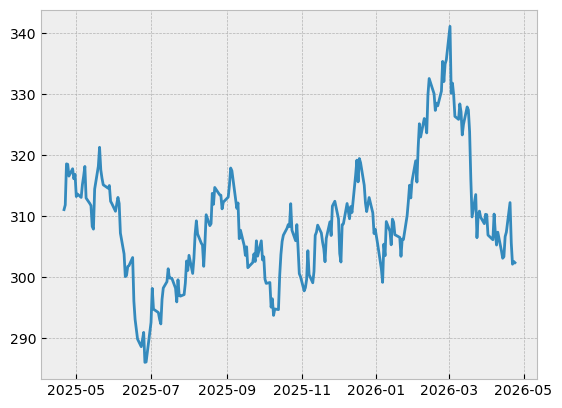

In [1085]:
plt.plot(df.index, df.open)

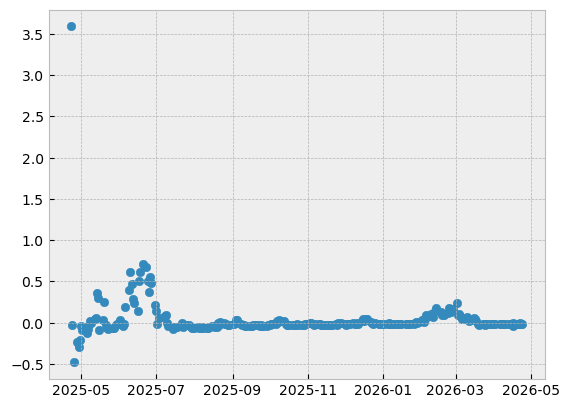

In [1086]:
plt.scatter(x=diff_rolling_deviations_df.index, y=diff_rolling_deviations_df.deviation)

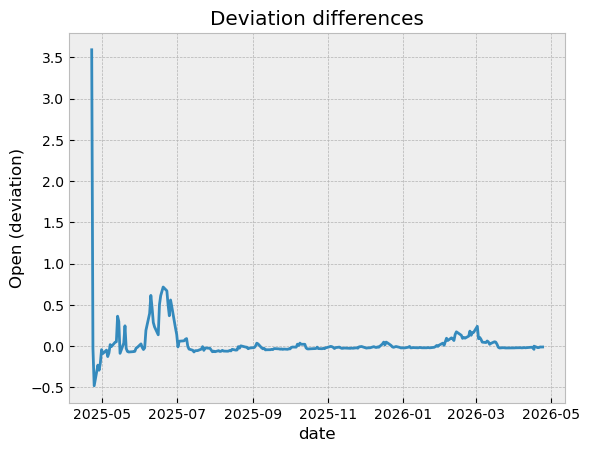

In [1087]:
# deviation by month
plt.plot(diff_rolling_deviations)
plt.title("Deviation differences") 
plt.ylabel("Open (deviation)") 
plt.xlabel("date")
plt.show()

In [1088]:
open

date
2025-04-21    311.00
2025-04-22    311.76
2025-04-23    318.50
2025-04-24    318.43
2025-04-25    316.50
               ...  
2026-04-20    312.15
2026-04-21    305.55
2026-04-22    302.05
2026-04-23    302.50
2026-04-24    302.29
Name: open, Length: 256, dtype: float64

In [1089]:
start_date.month

4

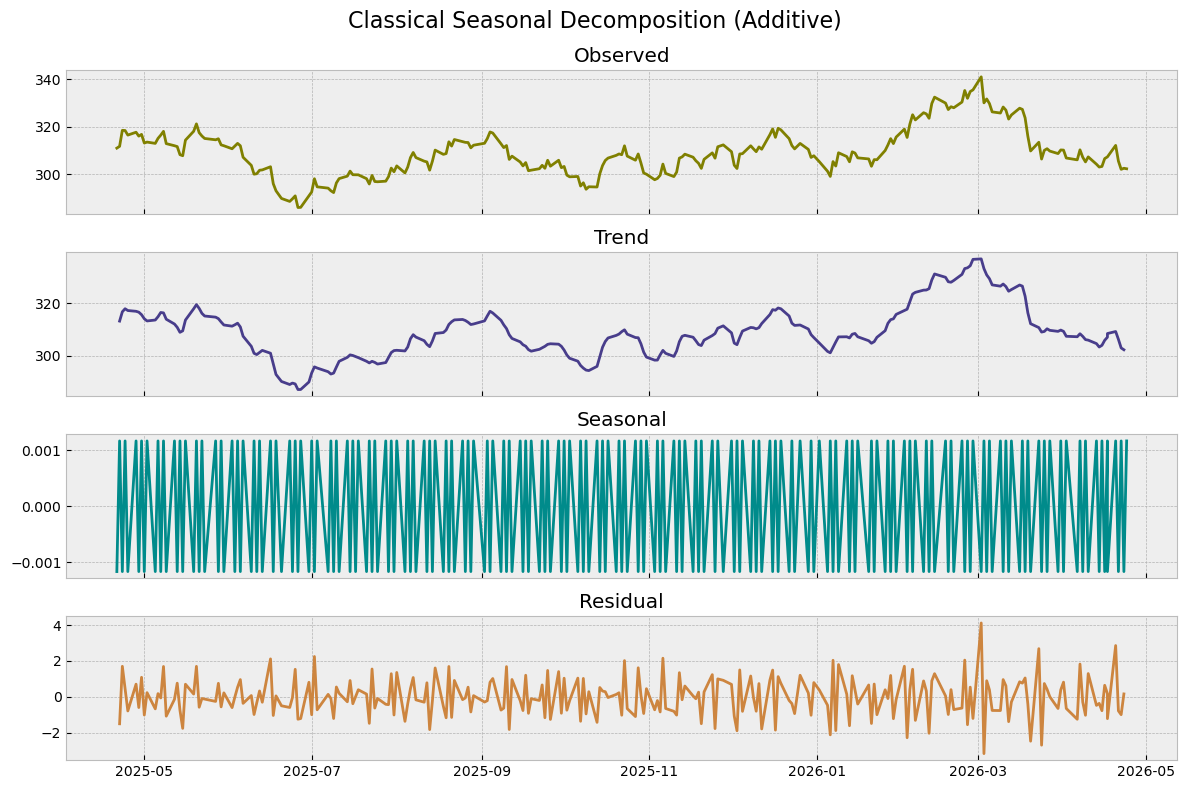

In [1090]:
series = df['open']
result = seasonal_decompose(series, model='additive', period=2)

fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

axs[0].plot(result.observed, color='olive')
axs[0].set_title('Observed')

axs[1].plot(result.trend, color='darkslateblue')
axs[1].set_title('Trend')

axs[2].plot(result.seasonal, color='darkcyan')
axs[2].set_title('Seasonal')

axs[3].plot(result.resid, color='peru')
axs[3].set_title('Residual')

plt.suptitle('Classical Seasonal Decomposition (Additive)', fontsize=16)
plt.tight_layout()
plt.show()

In [1091]:
# we know there is seasonality in "open", so we can use method 2

month_deviations=open.groupby(lambda d:d.week).std()

In [1092]:
month_deviations

date
1     2.145342
2     3.829234
3     1.680783
4     1.452753
5     2.257636
6     3.674799
7     3.622986
8     1.150507
9     2.292396
10    5.546064
11    1.943412
12    7.829123
13    2.533097
14    1.599945
15    1.921986
16    2.010122
17    6.607494
18    2.008121
19    2.237963
20    2.760621
21    2.343175
22    1.487982
23    2.268552
24    1.500560
25    5.706735
26    2.182469
27    3.113170
28    2.427350
29    0.793839
30    1.398707
31    2.632461
32    3.489817
33    3.008667
34    2.840162
35    1.086200
36    2.214746
37    2.900936
38    1.723781
39    1.425956
40    2.852371
41    2.079418
42    4.950114
43    1.769090
44    3.637846
45    2.602378
46    4.246707
47    1.815605
48    2.558567
49    3.230306
50    0.961161
51    1.677519
52    1.808167
Name: open, dtype: float64

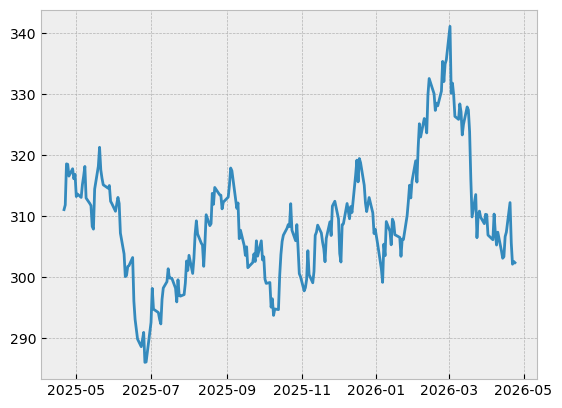

In [1093]:
plt.plot(df.index, df.open)

Text(0, 0.5, '$')

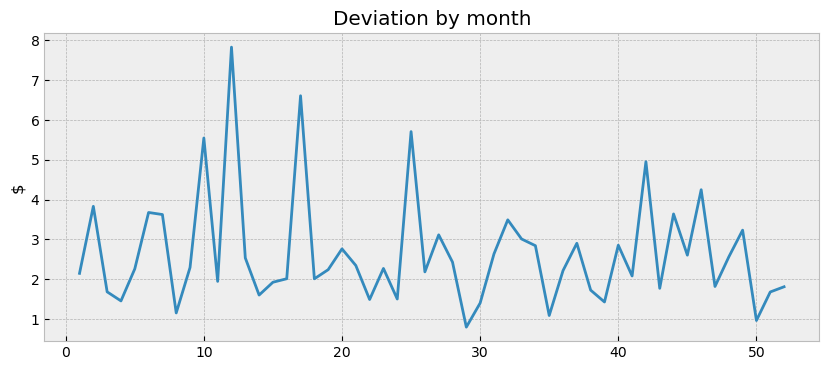

In [1094]:
plt.figure(figsize=(10,4)) 
plt.plot(month_deviations)
plt.title("Deviation by month") 
plt.ylabel("$")

In [1095]:
min_dev=2
curr_anomaly = None 
for date in month_deviations.index: 
    other_date = month_deviations[month_deviations.index != date]
    curr_dev = other_date.std() 
    if curr_dev < min_dev:
        min_dev = curr_dev 
        curr_anomaly=date 

In [1096]:
curr_anomaly
# anomaly is at 13th apritl 2026

12

In [1097]:
from statsmodels.tsa.seasonal import STL

<Axes: xlabel='date'>

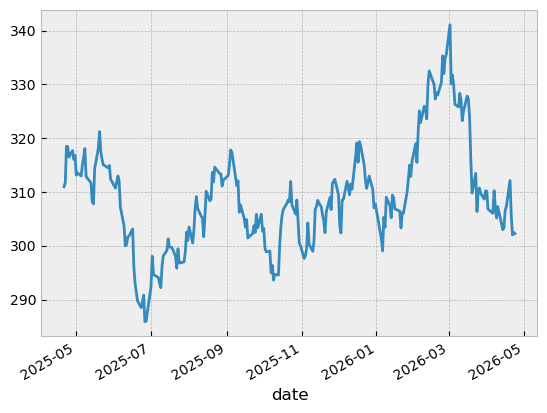

In [1098]:
df['open'].plot(kind='line')

In [1099]:
df

,date,open,high,low,close,adjusted_close,volume
date,,,,,,,
2025-04-21,2025-04-21,311.00,311.28,305.12,308.72,301.7516,2669900
2025-04-22,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
2025-04-23,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
2025-04-24,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
2025-04-25,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900
...,...,...,...,...,...,...,...
2026-04-20,2026-04-20,312.15,312.53,305.95,306.94,306.9400,2395200
2026-04-21,2026-04-21,305.55,306.15,300.97,301.84,301.8400,2708100
2026-04-22,2026-04-22,302.05,302.91,299.83,300.07,300.0700,2845600


In [ ]:
from statsmodels.tsa.seasonal import STL
open_price = pd.DataFrame(df[['open', 'volume', 'high', 'low', 'adjusted_close']])


stl = STL(open_price['open'], period=2) 
result = stl.fit()

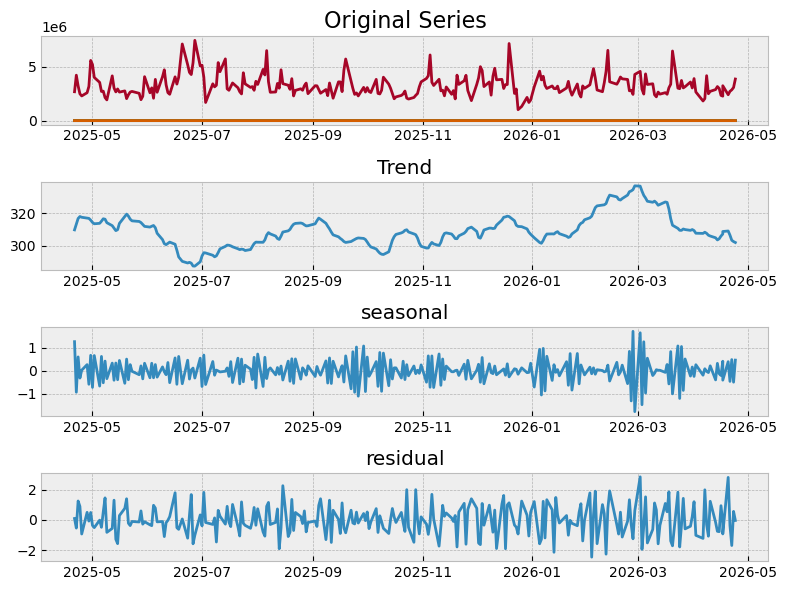

In [1101]:
seasonal, trend, resid = result.seasonal, result.trend, result.resid 

plt.figure(figsize=(8,6)) 
plt.subplot(4,1,1) 
plt.plot(open_price) 
plt.title("Original Series", fontsize=16) 

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend") 

plt.subplot(4,1,3) 
plt.plot(seasonal) 
plt.title("seasonal") 

plt.subplot(4,1,4) 
plt.plot(resid) 
plt.title("residual")
plt.tight_layout()

In [1102]:
open_price.head()

,open,volume,high,low,adjusted_close
date,,,,,
2025-04-21,311.00,2669900,311.28,305.12,301.7516
2025-04-22,311.76,4200700,320.00,311.19,311.8778
2025-04-23,318.50,3210100,319.90,314.79,311.2913
2025-04-24,318.43,2479500,318.89,313.53,309.0823
2025-04-25,316.50,2282900,321.78,315.03,309.5906


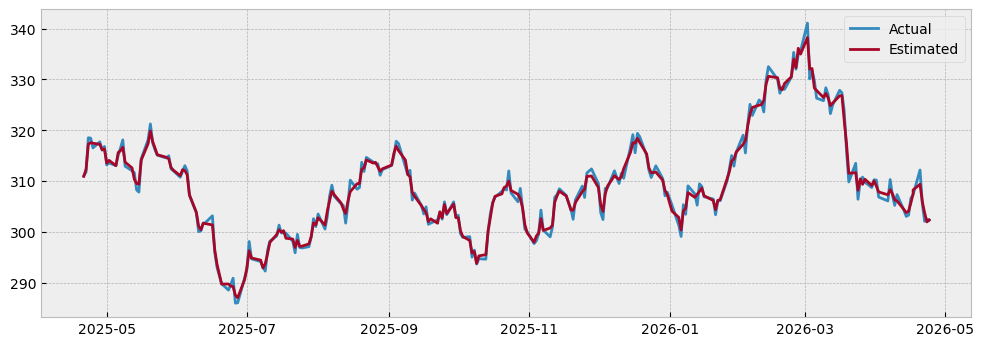

In [1103]:
estimated = trend + seasonal 
plt.figure(figsize=(12,4)) 
plt.plot(open_price.index, open_price.open) 
plt.plot(estimated) 
plt.legend(['Actual', 'Estimated'])
plt.show()

# anomaly detection

In [1104]:
resid_mu = resid.mean() 
resid_dev = resid.std() 

lower=resid_mu - 3 * resid_dev 
upper = resid_mu + 3 * resid_dev 

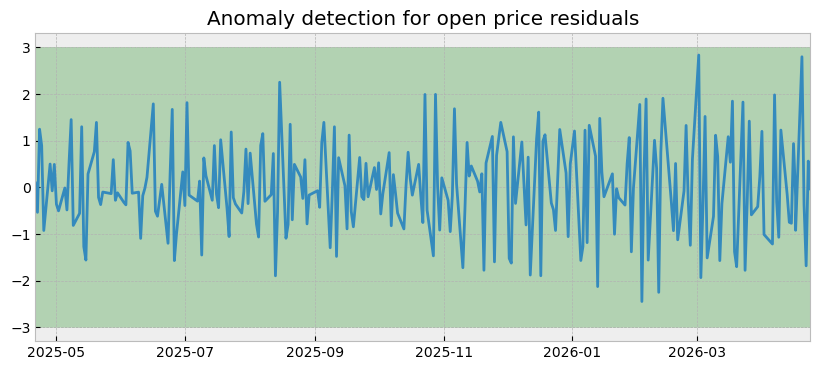

In [1105]:
# checking if datapoints fit within 3 * std of mean

plt.figure(figsize=(10,4)) 
plt.plot(resid) 
plt.fill_between([min(open_price.index), max(open_price.index)], lower, upper, color='g', alpha=0.25, linestyle='--')
plt.xlim(min(open_price.index), max(open_price.index))
plt.title("Anomaly detection for open price residuals")
plt.show()

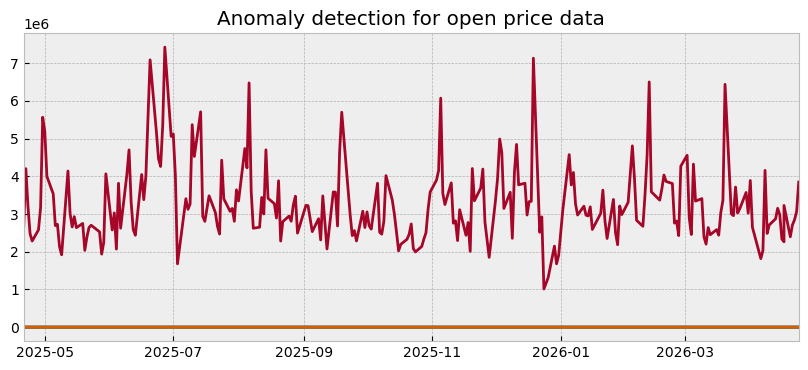

In [1106]:
# checking if datapoints fit within 3 * std of mean
open_mu = open_price['open'].mean() 
open_dev = open_price['open'].std() 

lower=open_mu - 3 * open_dev 
upper = open_mu + 3 * open_dev 
plt.figure(figsize=(10,4)) 
plt.plot(open_price) 
plt.fill_between([min(open_price.index), max(open_price.index)], lower, upper, color='g', alpha=0.3, linestyle='--')
plt.xlim(min(open_price.index), max(open_price.index))
plt.title("Anomaly detection for open price data")
plt.show()

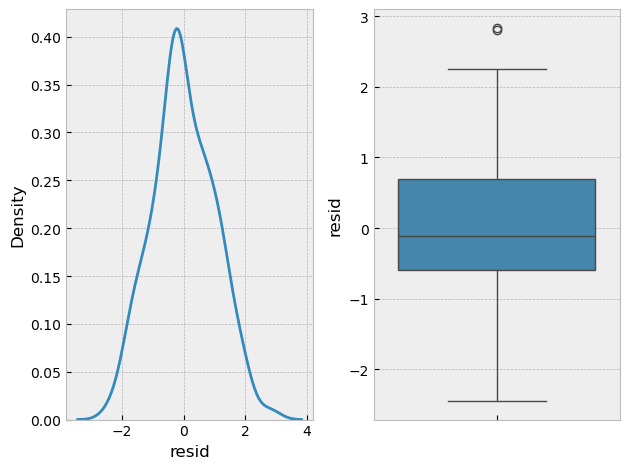

In [1107]:
# testing the assumptions of this technique

# 1. normal distribution of data
# 2. sensitive to extreme outliers (boxplot?)


fig, axes = plt.subplots(1,2) 

# normal distribution 
sns.kdeplot(x=resid, ax=axes[0])

# extreme outliers
sns.boxplot(data=resid, ax=axes[1])



plt.tight_layout()
plt.show()

# Calculating VWAP

In [1108]:
df.head()

,date,open,high,low,close,adjusted_close,volume
date,,,,,,,
2025-04-21,2025-04-21,311.00,311.28,305.12,308.72,301.7516,2669900
2025-04-22,2025-04-22,311.76,320.00,311.19,319.08,311.8778,4200700
2025-04-23,2025-04-23,318.50,319.90,314.79,318.48,311.2913,3210100
2025-04-24,2025-04-24,318.43,318.89,313.53,316.22,309.0823,2479500
2025-04-25,2025-04-25,316.50,321.78,315.03,316.74,309.5906,2282900


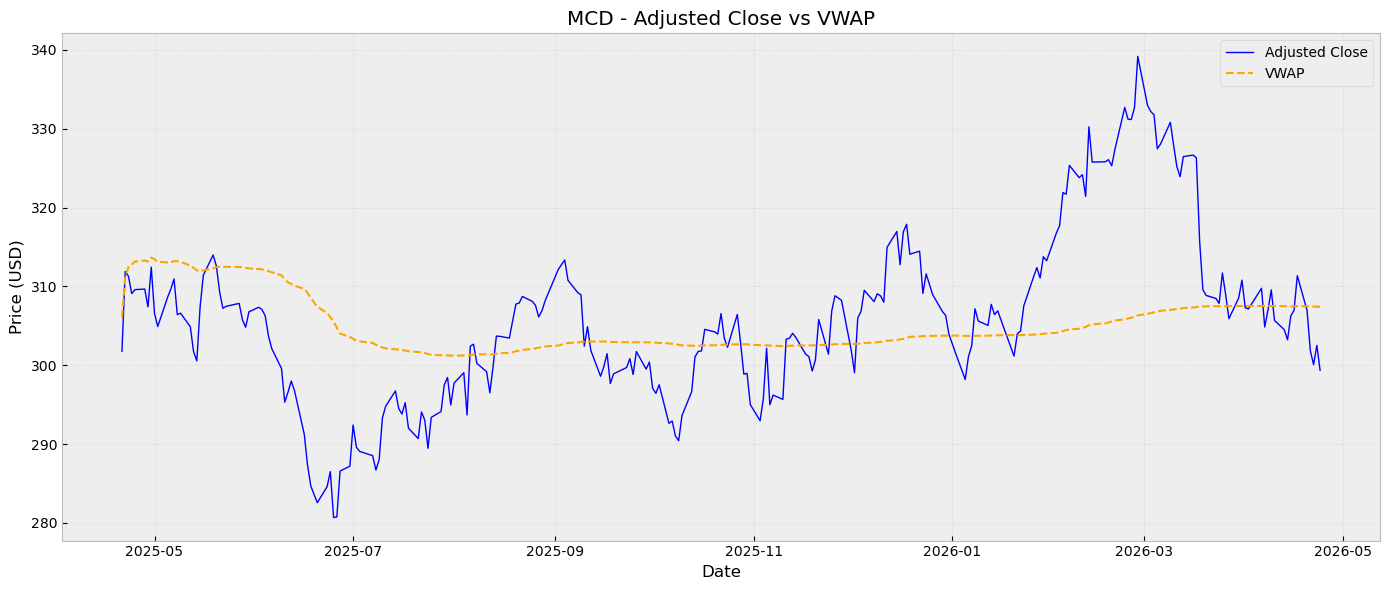

In [1109]:
# VWAP

df['date'] = pd.to_datetime(df['date'])
df = df.sort_index(ascending=True)

# Calculate VWAP
# VWAP = cumulative(price * volume) / cumulative(volume)
df['typical_price'] = (df['high'] + df['low'] + df['adjusted_close']) / 3
df['tp_x_vol'] = df['typical_price'] * df['volume']
df['vwap'] = df['tp_x_vol'].cumsum() / df['volume'].cumsum()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['adjusted_close'], label='Adjusted Close', color='blue', linewidth=1)
plt.plot(df['date'], df['vwap'], label='VWAP', color='orange', linewidth=1.5, linestyle='--')

plt.title("MCD - Adjusted Close vs VWAP")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("vwap_plot.png")
plt.show()

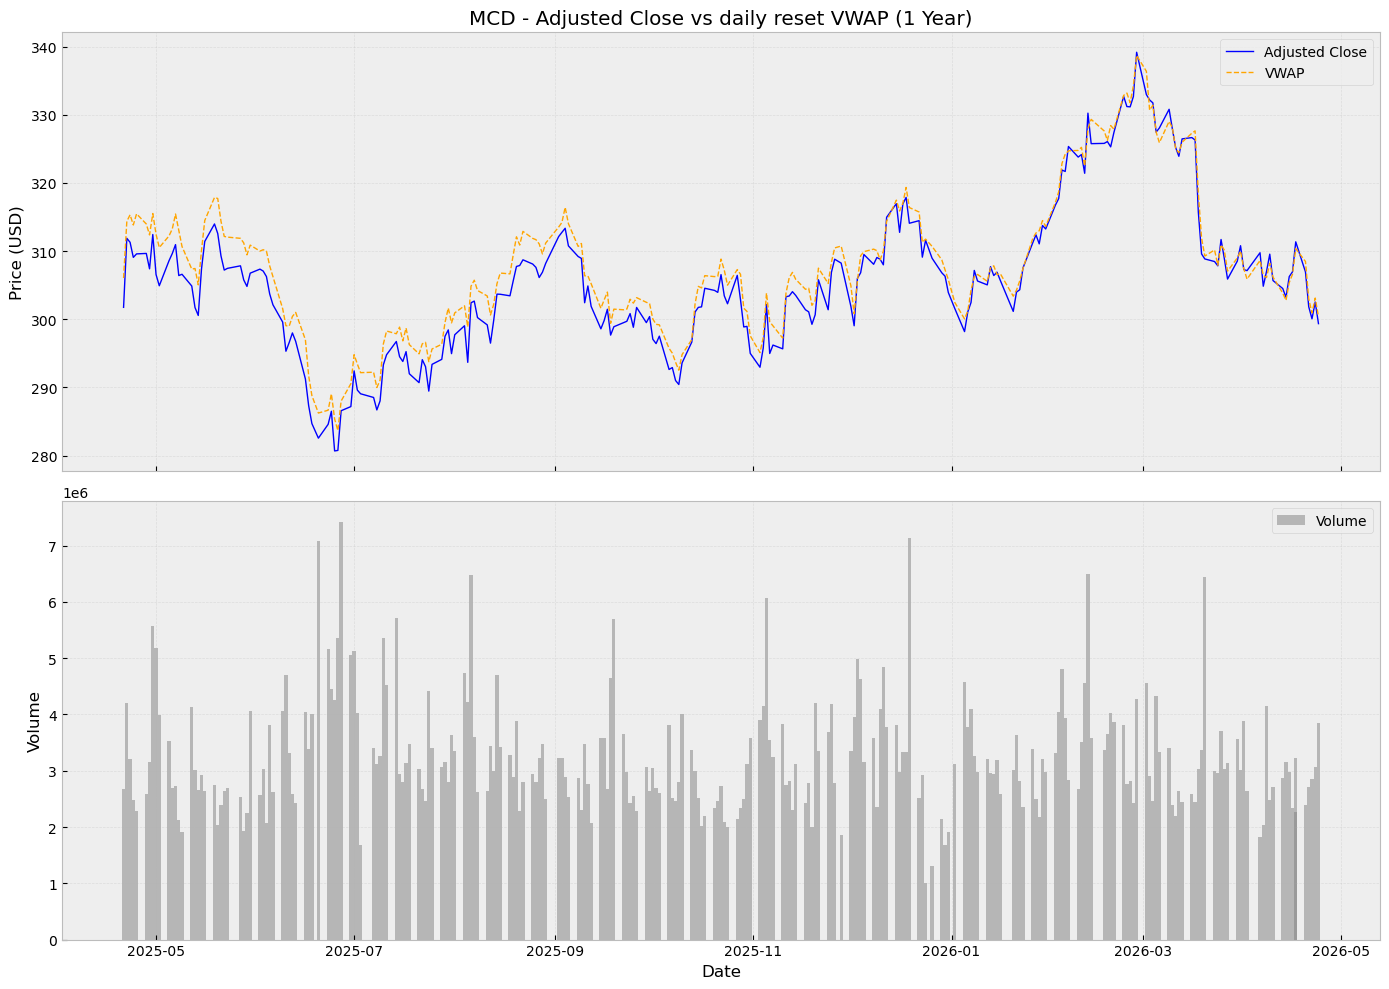

In [1110]:
df['date'] = pd.to_datetime(df['date'])
df.sort_index(ascending=True, inplace=True)

# Calculate typical price
df['typical_price'] = (df['high'] + df['low'] + df['adjusted_close']) / 3
df['tp_x_vol'] = df['typical_price'] * df['volume']

# Reset VWAP each day
df['vwap'] = df.groupby(df['date'].dt.date).apply(
    lambda g: g['tp_x_vol'].cumsum() / g['volume'].cumsum()
).reset_index(level=0, drop=True)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Price + VWAP
ax1.plot(df['date'], df['adjusted_close'], label='Adjusted Close', color='blue', linewidth=1)
ax1.plot(df['date'], df['vwap'], label='VWAP', color='orange', linewidth=1, linestyle='--')
ax1.set_title("MCD - Adjusted Close vs daily reset VWAP (1 Year)")
ax1.set_ylabel("Price (USD)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Volume bars
ax2.bar(df['date'], df['volume'], label='Volume', color='grey', alpha=0.5, width=1)
ax2.set_ylabel("Volume")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("vwap_plot.png")
plt.show()

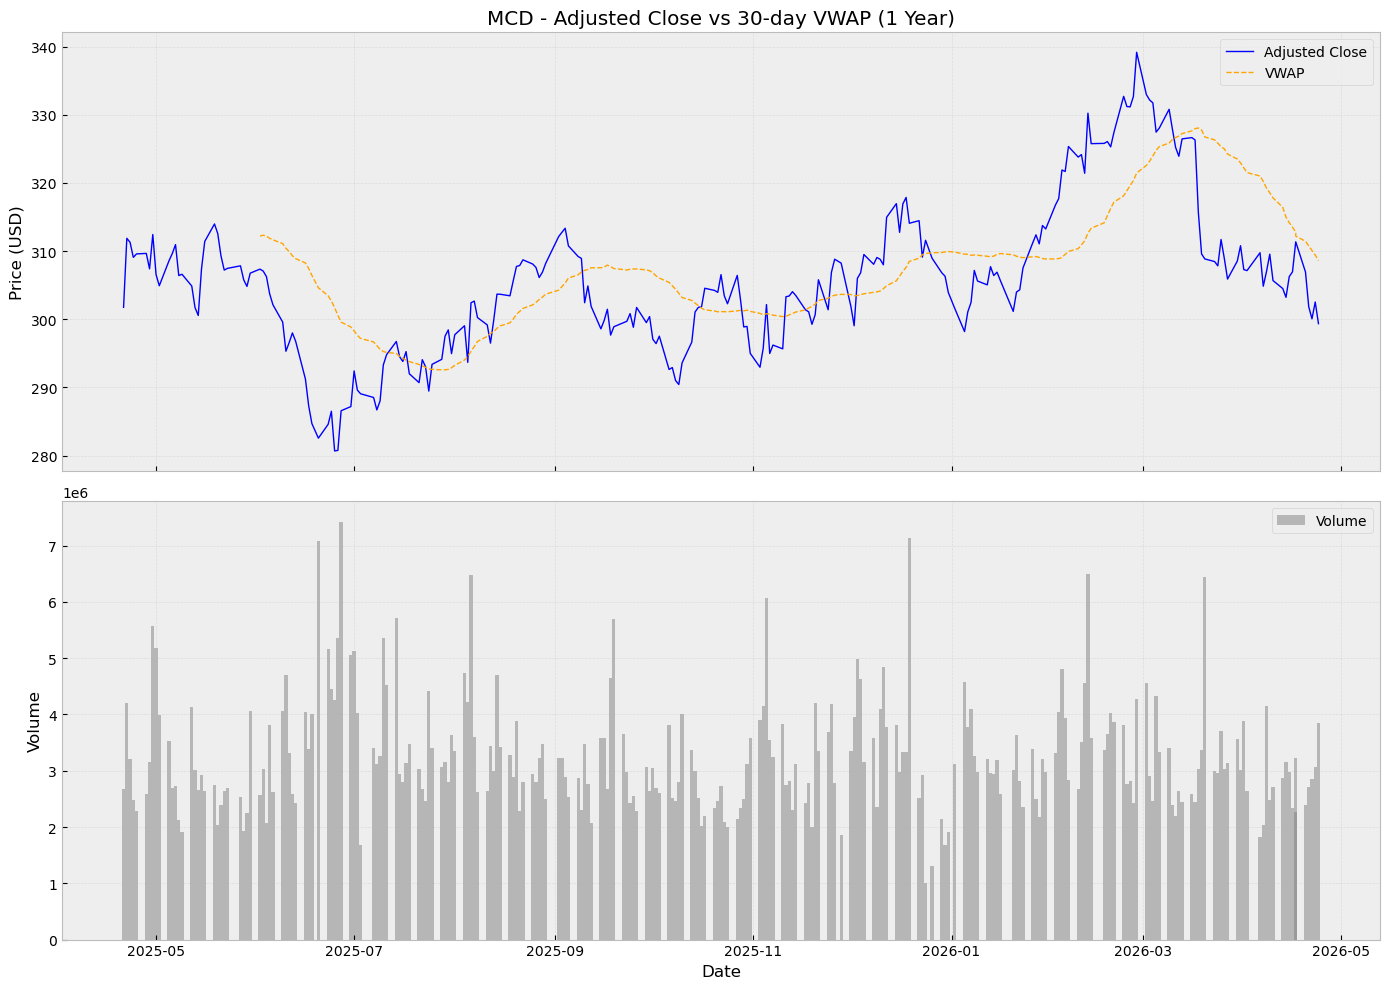

In [1111]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_index(ascending=True)

# Calculate typical price
df['typical_price'] = (df['high'] + df['low'] + df['adjusted_close']) / 3
df['tp_x_vol'] = df['typical_price'] * df['volume']

# Reset VWAP every 20 days
window = 30
df['vwap'] = (
    df['tp_x_vol'].rolling(window).sum() / df['volume'].rolling(window).sum()
)
# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Price + VWAP
ax1.plot(df['date'], df['adjusted_close'], label='Adjusted Close', color='blue', linewidth=1)
ax1.plot(df['date'], df['vwap'], label='VWAP', color='orange', linewidth=1, linestyle='--')
ax1.set_title("MCD - Adjusted Close vs 30-day VWAP (1 Year)")
ax1.set_ylabel("Price (USD)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Volume bars
ax2.bar(df['date'], df['volume'], label='Volume', color='grey', alpha=0.5, width=1)
ax2.set_ylabel("Volume")
ax2.set_xlabel("Date")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("vwap_plot.png")
plt.show()

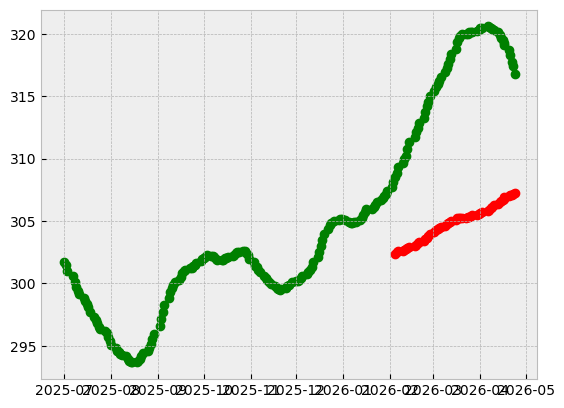

In [1112]:
df['ma50'] = df['adjusted_close'].rolling(50).mean()
df['ma200'] = df['adjusted_close'].rolling(200).mean()

fig, ax1=plt.subplots()

ax1.scatter(df['date'], df['ma50'], label='50-day MA', color='green', linewidth=1)
ax1.scatter(df['date'], df['ma200'], label='200-day MA', color='red', linewidth=1)

plt.show()

In [1113]:
ma_200_na = df['ma200'].dropna().values 
len(ma_200_na)

57

# testing for assumptions

In [1114]:
# statistical test for normality

# null hypothesis is that the data is normally distributed
import scipy.stats as stats 

stats.shapiro(resid)

# the residuals are normally distributed

ShapiroResult(statistic=0.9933890018368767, pvalue=0.3186945279426039)

In [1115]:
open_price

,open,volume,high,low,adjusted_close
date,,,,,
2025-04-21,311.00,2669900,311.28,305.12,301.7516
2025-04-22,311.76,4200700,320.00,311.19,311.8778
2025-04-23,318.50,3210100,319.90,314.79,311.2913
2025-04-24,318.43,2479500,318.89,313.53,309.0823
2025-04-25,316.50,2282900,321.78,315.03,309.5906
...,...,...,...,...,...
2026-04-20,312.15,2395200,312.53,305.95,306.9400
2026-04-21,305.55,2708100,306.15,300.97,301.8400
2026-04-22,302.05,2845600,302.91,299.83,300.0700


# creating a model

In [1116]:
from sklearn.model_selection import train_test_split

In [1117]:
open_price

,open,volume,high,low,adjusted_close
date,,,,,
2025-04-21,311.00,2669900,311.28,305.12,301.7516
2025-04-22,311.76,4200700,320.00,311.19,311.8778
2025-04-23,318.50,3210100,319.90,314.79,311.2913
2025-04-24,318.43,2479500,318.89,313.53,309.0823
2025-04-25,316.50,2282900,321.78,315.03,309.5906
...,...,...,...,...,...
2026-04-20,312.15,2395200,312.53,305.95,306.9400
2026-04-21,305.55,2708100,306.15,300.97,301.8400
2026-04-22,302.05,2845600,302.91,299.83,300.0700


In [1118]:
open_price

,open,volume,high,low,adjusted_close
date,,,,,
2025-04-21,311.00,2669900,311.28,305.12,301.7516
2025-04-22,311.76,4200700,320.00,311.19,311.8778
2025-04-23,318.50,3210100,319.90,314.79,311.2913
2025-04-24,318.43,2479500,318.89,313.53,309.0823
2025-04-25,316.50,2282900,321.78,315.03,309.5906
...,...,...,...,...,...
2026-04-20,312.15,2395200,312.53,305.95,306.9400
2026-04-21,305.55,2708100,306.15,300.97,301.8400
2026-04-22,302.05,2845600,302.91,299.83,300.0700


In [1119]:
open_price.index = pd.to_datetime(df['date'])
open_price.date = pd.to_datetime(df['date'])


/var/folders/4y/8v3hsc192dd3bhhzh6m1dcb40000gn/T/ipykernel_10698/3324650433.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  open_price.date = pd.to_datetime(df['date'])


In [1120]:
open_price.head()

,open,volume,high,low,adjusted_close
date,,,,,
2025-04-21,311.00,2669900,311.28,305.12,301.7516
2025-04-22,311.76,4200700,320.00,311.19,311.8778
2025-04-23,318.50,3210100,319.90,314.79,311.2913
2025-04-24,318.43,2479500,318.89,313.53,309.0823
2025-04-25,316.50,2282900,321.78,315.03,309.5906


In [1121]:
lagged_volume = open_price['volume'].values
lagged_volume = np.insert(lagged_volume, 0, 0)
lagged_volume = lagged_volume[:-1]

open_price['lagged_volume'] = lagged_volume 

# lagged adjusted close
lagged_adjusted_close = open_price['adjusted_close'].values 
lagged_adjusted_close = np.insert(lagged_adjusted_close, 0, 0) 
lagged_adjusted_close = lagged_adjusted_close[:-1]
open_price['lagged_adjusted_close'] = lagged_adjusted_close


# lagged adjusted high
lagged_high = open_price['high'].values 
lagged_high = np.insert(lagged_high, 0, 0) 
lagged_high = lagged_high[:-1]
open_price['lagged_high'] = lagged_high 

# lagged low 
lagged_low = open_price['low'].values 
lagged_low = np.insert(lagged_low, 0, 0) 
lagged_low = lagged_low[:-1]
open_price['lagged_low'] = lagged_low 

open_price.head()









,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
date,,,,,,,,,
2025-04-21,311.00,2669900,311.28,305.12,301.7516,0,0.0000,0.00,0.00
2025-04-22,311.76,4200700,320.00,311.19,311.8778,2669900,301.7516,311.28,305.12
2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19
2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79
2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53


In [1122]:
open_price

,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
date,,,,,,,,,
2025-04-21,311.00,2669900,311.28,305.12,301.7516,0,0.0000,0.00,0.00
2025-04-22,311.76,4200700,320.00,311.19,311.8778,2669900,301.7516,311.28,305.12
2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19
2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79
2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53
...,...,...,...,...,...,...,...,...,...
2026-04-20,312.15,2395200,312.53,305.95,306.9400,3225500,311.3600,312.54,307.20
2026-04-21,305.55,2708100,306.15,300.97,301.8400,2395200,306.9400,312.53,305.95
2026-04-22,302.05,2845600,302.91,299.83,300.0700,2708100,301.8400,306.15,300.97


In [1123]:
# testing xgboost


from xgboost import XGBRegressor 

In [1124]:
open_price.head()

,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
date,,,,,,,,,
2025-04-21,311.00,2669900,311.28,305.12,301.7516,0,0.0000,0.00,0.00
2025-04-22,311.76,4200700,320.00,311.19,311.8778,2669900,301.7516,311.28,305.12
2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19
2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79
2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53


In [1125]:
open_price = open_price.iloc[1:]

In [1126]:
open_price

,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low
date,,,,,,,,,
2025-04-22,311.76,4200700,320.00,311.19,311.8778,2669900,301.7516,311.28,305.12
2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19
2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79
2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53
2025-04-28,317.70,2578300,318.02,314.25,309.6590,2282900,309.5906,321.78,315.03
...,...,...,...,...,...,...,...,...,...
2026-04-20,312.15,2395200,312.53,305.95,306.9400,3225500,311.3600,312.54,307.20
2026-04-21,305.55,2708100,306.15,300.97,301.8400,2395200,306.9400,312.53,305.95
2026-04-22,302.05,2845600,302.91,299.83,300.0700,2708100,301.8400,306.15,300.97


In [1234]:
open_price['day'] = open_price.index.day 
open_price['month'] = open_price.index.month
open_price['year'] = open_price.index.year 
open_price = open_price.sort_index(ascending=True)
X = open_price[['day', 'month', 'year', 'lagged_volume', 'lagged_high', 'lagged_low']]

# deleting the first row



X_train = X.head(204) 
X_test = X.tail(51)



Y_train = open_price['open'].head(204).values.reshape(-1,1) 
Y_test = open_price.open.tail(51).values.reshape(-1,1)

In [1235]:
model2 = XGBRegressor() 
model2.fit(X_train, Y_train)
predictions2 = model2.predict(X_test) 
predictions2 = pd.DataFrame(predictions2) 
predictions2.index = X_test.index 
predictions2.columns = ['prediction']


In [1236]:
Y_test_df = pd.DataFrame(Y_test) 
Y_test_df.index = X_test.index 

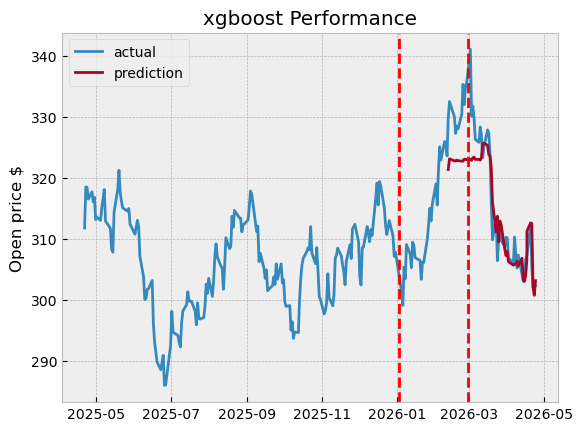

In [1237]:
pred = model2.predict(X_test) 



plt.plot(open_price.index, open_price.open) 

plt.plot(X_test.index, pred) 


plt.axvline(x=pd.to_datetime('2026-02-28'), linestyle='--', color='r') 
plt.axvline(x=pd.to_datetime('2026-01-03'), linestyle='--', color='r')

plt.title("xgboost Performance")
plt.ylabel("Open price $")

plt.legend(['actual', 'prediction'])

Text(0, 0.5, ' pred')

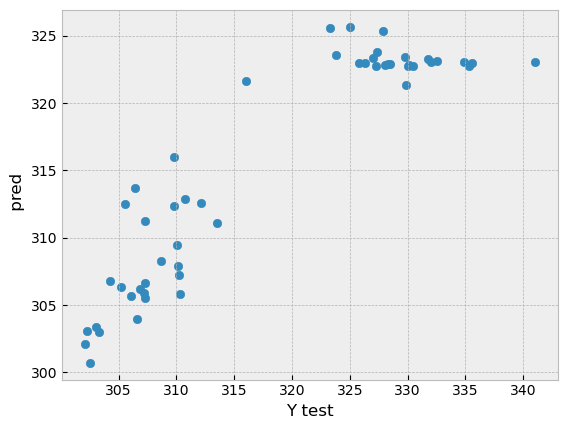

In [1150]:
plt.scatter(Y_test, pred) 

plt.xlabel("Y test") 
plt.ylabel(" pred")

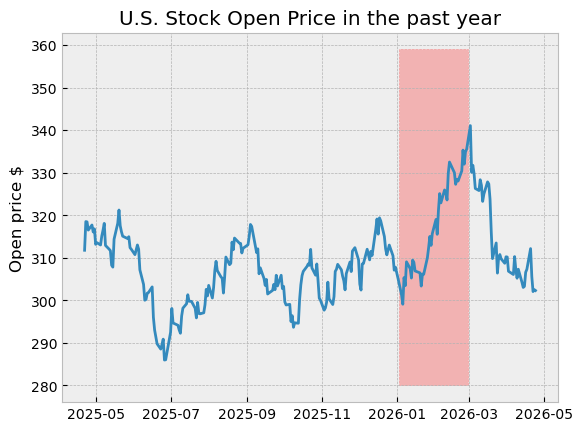

In [1151]:
plt.plot(open_price.index, open_price.open) 





plt.fill_between(['2026-01-03', '2026-02-28'], 280, 359, linestyle='--', alpha=0.25, color='r')

plt.title("U.S. Stock Open Price in the past year")
plt.ylabel("Open price $")

plt.show()

In [1152]:
# metrics

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [1153]:
print (root_mean_squared_error(y_pred=predictions2, y_true=Y_test))
print (mean_absolute_error(y_pred=predictions2, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=predictions2))

5.823280372498845
4.341828661151957
0.749851180597274


In [1154]:
# optimising the model

from sklearn.model_selection import GridSearchCV

In [1241]:
params = {
    'max_depth': [6, 10, 20, 30, 40, 50],
    'eta': [0.01, 0.1, 0.3],
    'tree_method': ['exact'],
    'min_child_weight': [0,1]

}


grid_search = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=params,
    verbose=3,
    scoring='r2',
    return_train_score=True
)

_ = grid_search.fit(X_train, Y_train) 

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV 1/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.818, test=0.509) total time=   0.1s
[CV 2/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.811, test=-0.095) total time=   0.0s
[CV 3/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.819, test=0.804) total time=   0.1s
[CV 4/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.823, test=0.651) total time=   0.0s
[CV 5/5] END eta=0.01, max_depth=6, min_child_weight=0, tree_method=exact;, score=(train=0.821, test=0.373) total time=   0.0s
[CV 1/5] END eta=0.01, max_depth=6, min_child_weight=1, tree_method=exact;, score=(train=0.818, test=0.509) total time=   0.0s
[CV 2/5] END eta=0.01, max_depth=6, min_child_weight=1, tree_method=exact;, score=(train=0.811, test=-0.095) total time=   0.1s
[CV 3/5] END eta=0.01, max_depth=6, min_child_w

In [1242]:
grid_search.best_params_

{'eta': 0.3, 'max_depth': 10, 'min_child_weight': 0, 'tree_method': 'exact'}

In [1243]:
grid_search.best_score_

0.7904173261010656

In [1244]:
X_test.head()

,day,month,year,lagged_volume,lagged_high,lagged_low
date,,,,,,
2026-02-12,12,2,2026,4553200,325.20,320.81
2026-02-13,13,2,2026,6499700,333.38,320.15
2026-02-17,17,2,2026,3587900,335.67,326.53
2026-02-18,18,2,2026,3367200,332.08,325.00
2026-02-19,19,2,2026,3661800,328.80,323.83


In [1245]:
grid_predictions = grid_search.predict(X_test)
grid_predictions_df = pd.DataFrame(grid_predictions) 
grid_predictions_df.index = X_test.index 
grid_predictions_df.columns = ['prediction']

In [1246]:
print (root_mean_squared_error(y_pred=grid_predictions, y_true=Y_test))
print (mean_absolute_error(y_pred=grid_predictions, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=grid_predictions))

5.704285987778904
4.314621342677692
0.7599699373342843


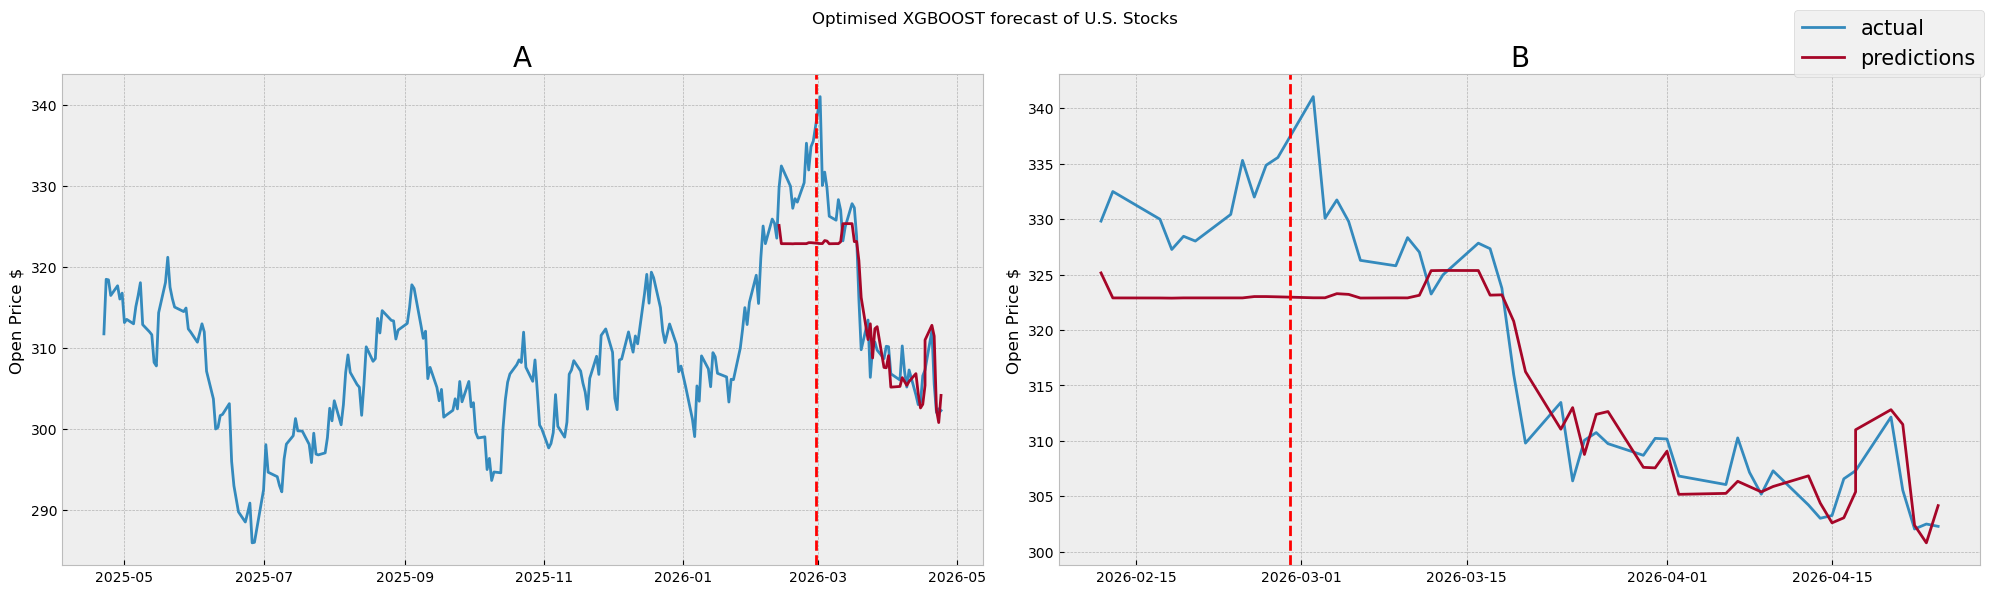

In [ ]:

fig, axes=plt.subplots(1,2, figsize=(20,6)) 
fig.suptitle("Optimised XGBOOST forecast of U.S. Stocks")

axes[0].plot(open_price.index, open_price.open) 
axes[0].plot(X_test.index, grid_predictions) 
axes[0].axvline(pd.to_datetime('2026-02-28'), linestyle='--', color='r')
axes[0].set_title("A", fontsize=20)
axes[0].set_ylabel("Open Price $")

axes[1].plot(X_test.index, Y_test) 
axes[1].plot(X_test.index, grid_predictions) 
axes[1].axvline(pd.to_datetime('2026-02-28'), linestyle='--', color='r')
axes[1].set_title("B", fontsize=20)
axes[1].set_ylabel("Open Price $")

fig.legend(['actual', 'predictions'], fontsize=15)
plt.tight_layout()
plt.show()

In [1167]:
X_train

,day,month,year,lagged_volume,lagged_high,lagged_low
date,,,,,,
2025-04-22,22,4,2025,2669900,311.28,305.12
2025-04-23,23,4,2025,4200700,320.00,311.19
2025-04-24,24,4,2025,3210100,319.90,314.79
2025-04-25,25,4,2025,2479500,318.89,313.53
2025-04-28,28,4,2025,2282900,321.78,315.03
...,...,...,...,...,...,...
2026-02-05,5,2,2026,4805900,326.95,319.70
2026-02-06,6,2,2026,3936800,328.06,322.95
2026-02-09,9,2,2026,2831900,327.54,321.24


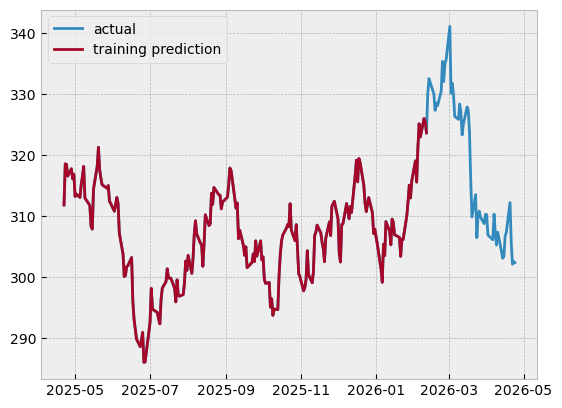

In [1248]:
train_pred = grid_search.predict(X_train)

plt.plot(open_price.index, open_price.open) 

plt.plot(X_train.index, train_pred)

plt.legend(['actual', 'training prediction'])

In [1170]:
r2_score(y_true=Y_train, y_pred=train_pred)

0.9999999926259391

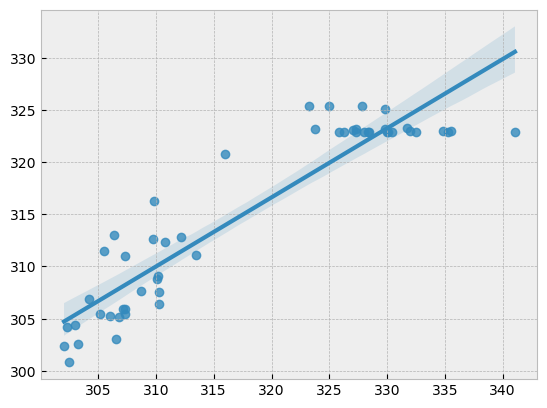

In [1163]:
sns.regplot(x=Y_test, y=grid_predictions)

plt.show()

In [1164]:
X

,day,month,year,lagged_volume,lagged_high,lagged_low
date,,,,,,
2025-04-22,22,4,2025,2669900,311.28,305.12
2025-04-23,23,4,2025,4200700,320.00,311.19
2025-04-24,24,4,2025,3210100,319.90,314.79
2025-04-25,25,4,2025,2479500,318.89,313.53
2025-04-28,28,4,2025,2282900,321.78,315.03
...,...,...,...,...,...,...
2026-04-20,20,4,2026,3225500,312.54,307.20
2026-04-21,21,4,2026,2395200,312.53,305.95
2026-04-22,22,4,2026,2708100,306.15,300.97


# incorporating news feed data

In [1165]:
import sys 
sys.path.append("../scripts/")
sys.path.append("../models/sentiment_analyser")

import re

In [1171]:
# incorporating news text

news = pd.read_csv("../financial_data/news/news_27_4_2026.csv")

In [1172]:
news = news.sort_values(['date'], ascending=True)

In [1173]:
news['date'] = pd.to_datetime(news['date'])
news

,date,heading,text
39,2025-04-01,unknown,Middle Eastern crisis \n Gaza war \n Israeli i...
107,2025-04-10,unknown,Syrian civil war \n Western Syria clashes \n 2...
143,2025-04-11,unknown,Gaza war \n Gaza Strip evacuations \n Indonesi...
144,2025-04-12,unknown,Sudanese Civil War \n Siege of El Fasher \n Za...
145,2025-04-13,unknown,Russian invasion of Ukraine \n Attacks on civi...
...,...,...,...
49,2025-09-05,unknown,Gaza war \n Gaza war hostage crisis \n Hamas ...
83,2025-09-06,unknown,Insurgency in Khyber Pakhtunkhwa \n At least o...
84,2025-09-07,unknown,Middle Eastern crisis \n Gaza war \n Israeli i...
85,2025-09-08,unknown,Middle Eastern crisis \n Israeli–Palestinian c...


In [1209]:
news.sort_values(['date'],ascending=True).tail(20)

,date,text,sentiment
429,2026-03-12,middle eastern crisis 2026 iran war 2026 str...,0
430,2026-03-13,middle eastern crisis 2026 iran war 2026 int...,2
431,2026-03-14,middle eastern crisis 2026 iran war 2026 ira...,2
438,2026-03-15,middle eastern crisis israeli–palestinian con...,2
439,2026-03-16,middle eastern crisis 2026 iran war 2026 str...,2
440,2026-03-17,middle eastern crisis 2026 iran war 2026 ira...,2
441,2026-03-18,middle eastern crisis 2026 iran war 2026 sou...,2
442,2026-03-19,2026 iran war 2026 iranian strikes on israel ...,0
443,2026-03-20,middle eastern crisis 2026 iran war 2026 str...,2
444,2026-03-21,middle eastern crisis 2026 iran war attack o...,2


In [1198]:
news.isna().sum()

date         0
text         0
sentiment    0
dtype: int64

In [1200]:
a = news.sort_values(['date'],ascending=True) 

a.tail(20)

,date,text,sentiment
429,2026-03-12,middle eastern crisis 2026 iran war 2026 str...,0
430,2026-03-13,middle eastern crisis 2026 iran war 2026 int...,2
431,2026-03-14,middle eastern crisis 2026 iran war 2026 ira...,2
438,2026-03-15,middle eastern crisis israeli–palestinian con...,2
439,2026-03-16,middle eastern crisis 2026 iran war 2026 str...,2
440,2026-03-17,middle eastern crisis 2026 iran war 2026 ira...,2
441,2026-03-18,middle eastern crisis 2026 iran war 2026 sou...,2
442,2026-03-19,2026 iran war 2026 iranian strikes on israel ...,0
443,2026-03-20,middle eastern crisis 2026 iran war 2026 str...,2
444,2026-03-21,middle eastern crisis 2026 iran war attack o...,2


In [1174]:
news['text'] = news['text'].str.replace("\n", "")
news

,date,heading,text
39,2025-04-01,unknown,Middle Eastern crisis Gaza war Israeli invas...
107,2025-04-10,unknown,Syrian civil war Western Syria clashes 2025 ...
143,2025-04-11,unknown,Gaza war Gaza Strip evacuations Indonesia i...
144,2025-04-12,unknown,Sudanese Civil War Siege of El Fasher Zamzam...
145,2025-04-13,unknown,Russian invasion of Ukraine Attacks on civili...
...,...,...,...
49,2025-09-05,unknown,Gaza war Gaza war hostage crisis Hamas rele...
83,2025-09-06,unknown,Insurgency in Khyber Pakhtunkhwa At least one...
84,2025-09-07,unknown,Middle Eastern crisis Gaza war Israeli invas...
85,2025-09-08,unknown,Middle Eastern crisis Israeli–Palestinian con...


In [1175]:
news.text = news.text.str.lower()

In [1176]:
news[news.date == '2025-06-02']

,date,heading,text
42,2025-06-02,unknown,somali civil war 2025 shabelle offensive al-...


In [1177]:
np.unique(news.date.isna())

array([False])

In [1178]:
news.drop(['heading'],axis=1,inplace=True)

In [1179]:
news.isna().sum()

date    0
text    0
dtype: int64

In [1180]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import spacy
stop_words = list(set(stopwords.words('english')))
nlp = spacy.load("en_core_web_sm")
def lemmatize(text):
    doc = nlp(text)
    # Turn it into tokens, ignoring the punctuation
    tokens = [token for token in doc if not token.is_punct]
    # Convert those tokens into lemmas, EXCEPT the pronouns, we'll keep those.
    lemmas = [token.lemma_ if token.pos_ != 'PRON' else token.orth_ for token in tokens]
    return lemmas



In [1181]:
# performing some one hot encoding

sentiment_model = joblib.load("../models/sentiment_analyser/sentiment_analyser.pkl") 
sentiment_vectoriser = joblib.load("../models/sentiment_analyser/sentiment_vectoriser.pkl") 

def sentiment(text): 
    text_cleaned = re.sub("[^a-zA-Z]", " ", text)

    # analysing

    text_cleaned_tfidf = sentiment_vectoriser.transform([text_cleaned])

    prediction = sentiment_model.predict(text_cleaned_tfidf)
    return prediction[0]

news['sentiment'] = news['text'].apply(sentiment)

/opt/miniconda3/envs/news_project/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'ve", 'could', 'far', 'might', 'must', 'need', 'shall', 'win', 'would'] not in stop_words.
  warnings.warn(


In [1183]:
open_price.head()

,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year
date,,,,,,,,,,,,
2025-04-22,311.76,4200700,320.00,311.19,311.8778,2669900,301.7516,311.28,305.12,22,4,2025
2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19,23,4,2025
2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79,24,4,2025
2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53,25,4,2025
2025-04-28,317.70,2578300,318.02,314.25,309.6590,2282900,309.5906,321.78,315.03,28,4,2025


In [1184]:
open_price.reset_index(inplace=True)

In [1185]:
open_price

,date,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year
0,2025-04-22,311.76,4200700,320.00,311.19,311.8778,2669900,301.7516,311.28,305.12,22,4,2025
1,2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19,23,4,2025
2,2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79,24,4,2025
3,2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53,25,4,2025
4,2025-04-28,317.70,2578300,318.02,314.25,309.6590,2282900,309.5906,321.78,315.03,28,4,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,2026-04-20,312.15,2395200,312.53,305.95,306.9400,3225500,311.3600,312.54,307.20,20,4,2026
251,2026-04-21,305.55,2708100,306.15,300.97,301.8400,2395200,306.9400,312.53,305.95,21,4,2026
252,2026-04-22,302.05,2845600,302.91,299.83,300.0700,2708100,301.8400,306.15,300.97,22,4,2026
253,2026-04-23,302.50,3064300,304.89,301.92,302.5300,2845600,300.0700,302.91,299.83,23,4,2026


In [1186]:
open_price = pd.merge(open_price, news, how='left', on='date')

In [1187]:
open_price.columns

Index(['date', 'open', 'volume', 'high', 'low', 'adjusted_close',
       'lagged_volume', 'lagged_adjusted_close', 'lagged_high', 'lagged_low',
       'day', 'month', 'year', 'text', 'sentiment'],
      dtype='object')

In [1188]:
open_price.rename({"sentiment_x": "sentiment"},axis=1,inplace=True) 
open_price.drop(['text'],axis=1, inplace=True)

In [1189]:
open_price

,date,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
0,2025-04-22,311.76,4200700,320.00,311.19,311.8778,2669900,301.7516,311.28,305.12,22,4,2025,0.0
1,2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19,23,4,2025,2.0
2,2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79,24,4,2025,2.0
3,2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53,25,4,2025,0.0
4,2025-04-28,317.70,2578300,318.02,314.25,309.6590,2282900,309.5906,321.78,315.03,28,4,2025,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,2026-04-20,312.15,2395200,312.53,305.95,306.9400,3225500,311.3600,312.54,307.20,20,4,2026,NaN
251,2026-04-21,305.55,2708100,306.15,300.97,301.8400,2395200,306.9400,312.53,305.95,21,4,2026,NaN
252,2026-04-22,302.05,2845600,302.91,299.83,300.0700,2708100,301.8400,306.15,300.97,22,4,2026,NaN
253,2026-04-23,302.50,3064300,304.89,301.92,302.5300,2845600,300.0700,302.91,299.83,23,4,2026,NaN


In [1208]:
open_price[open_price.sentiment.isna()]

,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
date,,,,,,,,,,,,,
2026-04-01,310.17,3887300,311.00,304.00,307.29,3021300,310.79,311.68,307.54,1,4,2026,NaN
2026-04-02,306.83,2649100,307.50,303.03,307.14,3887300,307.29,311.00,304.00,2,4,2026,NaN
2026-04-06,306.06,1816000,310.31,305.81,309.76,2649100,307.14,307.50,303.03,6,4,2026,NaN
2026-04-07,310.27,2033700,310.30,304.22,304.85,1816000,309.76,310.31,305.81,7,4,2026,NaN
2026-04-08,307.16,4155100,308.25,303.10,307.01,2033700,304.85,310.30,304.22,8,4,2026,NaN
2026-04-09,305.19,2484700,311.10,303.99,309.55,4155100,307.01,308.25,303.10,9,4,2026,NaN
2026-04-10,307.30,2708600,308.70,304.18,305.68,2484700,309.55,311.10,303.99,10,4,2026,NaN
2026-04-13,304.22,2872100,304.90,302.10,304.51,2708600,305.68,308.70,304.18,13,4,2026,NaN
2026-04-14,303.02,3150100,303.58,301.53,303.22,2872100,304.51,304.90,302.10,14,4,2026,NaN


In [1193]:
open_price

,date,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
0,2025-04-22,311.76,4200700,320.00,311.19,311.8778,2669900,301.7516,311.28,305.12,22,4,2025,0.0
1,2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19,23,4,2025,2.0
2,2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79,24,4,2025,2.0
3,2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53,25,4,2025,0.0
4,2025-04-28,317.70,2578300,318.02,314.25,309.6590,2282900,309.5906,321.78,315.03,28,4,2025,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250,2026-04-20,312.15,2395200,312.53,305.95,306.9400,3225500,311.3600,312.54,307.20,20,4,2026,NaN
251,2026-04-21,305.55,2708100,306.15,300.97,301.8400,2395200,306.9400,312.53,305.95,21,4,2026,NaN
252,2026-04-22,302.05,2845600,302.91,299.83,300.0700,2708100,301.8400,306.15,300.97,22,4,2026,NaN
253,2026-04-23,302.50,3064300,304.89,301.92,302.5300,2845600,300.0700,302.91,299.83,23,4,2026,NaN


In [1194]:
open_price.index = pd.to_datetime(open_price['date']) 
open_price.drop(['date'], axis=1, inplace=True) 

open_price = open_price.sort_index(ascending=True)
open_price

,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
date,,,,,,,,,,,,,
2025-04-22,311.76,4200700,320.00,311.19,311.8778,2669900,301.7516,311.28,305.12,22,4,2025,0.0
2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19,23,4,2025,2.0
2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79,24,4,2025,2.0
2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53,25,4,2025,0.0
2025-04-28,317.70,2578300,318.02,314.25,309.6590,2282900,309.5906,321.78,315.03,28,4,2025,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-20,312.15,2395200,312.53,305.95,306.9400,3225500,311.3600,312.54,307.20,20,4,2026,NaN
2026-04-21,305.55,2708100,306.15,300.97,301.8400,2395200,306.9400,312.53,305.95,21,4,2026,NaN
2026-04-22,302.05,2845600,302.91,299.83,300.0700,2708100,301.8400,306.15,300.97,22,4,2026,NaN


In [1048]:
mlb.classes_

array(['armed conflicts and attacks', 'arts and culture',
       'business and economics', 'disasters and accidents',
       'health and environment', 'international relations',
       'law and crime and politics',
       'politics and elections and economics', 'science and technology',
       'sports'], dtype=object)

In [1197]:
# reimplementing hte model



X = open_price.drop(['open', 'low', 'volume', 'adjusted_close', 'high'], axis=1).reset_index().drop(['date'],axis=1)
y = open_price.open.values.reshape(-1,1) 
X

,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
0,2669900,301.7516,311.28,305.12,22,4,2025,0.0
1,4200700,311.8778,320.00,311.19,23,4,2025,2.0
2,3210100,311.2913,319.90,314.79,24,4,2025,2.0
3,2479500,309.0823,318.89,313.53,25,4,2025,0.0
4,2282900,309.5906,321.78,315.03,28,4,2025,0.0
...,...,...,...,...,...,...,...,...
250,3225500,311.3600,312.54,307.20,20,4,2026,NaN
251,2395200,306.9400,312.53,305.95,21,4,2026,NaN
252,2708100,301.8400,306.15,300.97,22,4,2026,NaN
253,2845600,300.0700,302.91,299.83,23,4,2026,NaN


In [1201]:
X.head()

,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
0,2669900,301.7516,311.28,305.12,22,4,2025,0.0
1,4200700,311.8778,320.00,311.19,23,4,2025,2.0
2,3210100,311.2913,319.90,314.79,24,4,2025,2.0
3,2479500,309.0823,318.89,313.53,25,4,2025,0.0
4,2282900,309.5906,321.78,315.03,28,4,2025,0.0


In [1202]:
X.isna().sum()

lagged_volume             0
lagged_adjusted_close     0
lagged_high               0
lagged_low                0
day                       0
month                     0
year                      0
sentiment                18
dtype: int64

In [1203]:
X_train = X.head(204)
X_test = X.tail(51) 

Y_train = np.reshape(y[0:204], (-1,1))
Y_test = np.reshape(y[204:255], (-1,1))

In [1204]:
np.shape(Y_test)

(51, 1)

In [1205]:
X_test.head()

,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
204,4553200,321.4145,325.20,320.81,12,2,2026,2.0
205,6499700,330.2352,333.38,320.15,13,2,2026,2.0
206,3587900,325.7602,335.67,326.53,17,2,2026,2.0
207,3367200,325.8000,332.08,325.00,18,2,2026,2.0
208,3661800,326.0685,328.80,323.83,19,2,2026,2.0


In [1206]:
X.isna().sum()

lagged_volume             0
lagged_adjusted_close     0
lagged_high               0
lagged_low                0
day                       0
month                     0
year                      0
sentiment                18
dtype: int64

In [1027]:
X_train.head()

,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,sentiment,day,month,year,armed conflicts and attacks,arts and culture,business and economics,disasters and accidents,health and environment,international relations,law and crime and politics,politics and elections and economics,science and technology,sports
0,2669900,301.7516,311.28,305.12,0,22,4,2025,1,0,0,1,0,0,1,1,0,0
1,4200700,311.8778,320.00,311.19,1,23,4,2025,1,0,0,1,1,1,1,0,0,0
2,3210100,311.2913,319.90,314.79,2,24,4,2025,1,1,0,1,0,1,1,1,1,1
3,2479500,309.0823,318.89,313.53,0,25,4,2025,1,1,1,1,0,1,1,0,0,0
4,2282900,309.5906,321.78,315.03,0,28,4,2025,1,0,1,1,0,0,1,1,0,0


In [1210]:
clf = XGBRegressor() 

clf.fit(X_train, Y_train) 

pred = clf.predict(X_test) 

In [1211]:
print (root_mean_squared_error(y_pred=pred, y_true=Y_test))
print (mean_absolute_error(y_pred=pred, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=pred))

5.568359408296932
4.2620408241421535
0.7712729259546953


In [1212]:
params = {
    'max_depth': [6, 10, 20, 30, 50],
    'eta': [0.01, 0.1, 0.2, 0.3, 0.001, 0.002, 0.003],
    'tree_method': ['exact'],
    'min_child_weight': [0],
    'n_estimators': [2]

}


grid_search = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=params,
    verbose=3,
    scoring='r2',
    return_train_score=True
)

_ = grid_search.fit(X_train, Y_train) 

Fitting 5 folds for each of 35 candidates, totalling 175 fits
[CV 1/5] END eta=0.01, max_depth=6, min_child_weight=0, n_estimators=2, tree_method=exact;, score=(train=0.035, test=-0.722) total time=   0.1s
[CV 2/5] END eta=0.01, max_depth=6, min_child_weight=0, n_estimators=2, tree_method=exact;, score=(train=0.035, test=-2.796) total time=   0.0s
[CV 3/5] END eta=0.01, max_depth=6, min_child_weight=0, n_estimators=2, tree_method=exact;, score=(train=0.035, test=0.015) total time=   0.0s
[CV 4/5] END eta=0.01, max_depth=6, min_child_weight=0, n_estimators=2, tree_method=exact;, score=(train=0.035, test=-0.014) total time=   0.0s
[CV 5/5] END eta=0.01, max_depth=6, min_child_weight=0, n_estimators=2, tree_method=exact;, score=(train=0.036, test=-0.908) total time=   0.0s
[CV 1/5] END eta=0.01, max_depth=10, min_child_weight=0, n_estimators=2, tree_method=exact;, score=(train=0.035, test=-0.722) total time=   0.0s
[CV 2/5] END eta=0.01, max_depth=10, min_child_weight=0, n_estimators=2, t

In [1213]:
plt.style.use("bmh")

In [1214]:
grid_search.best_params_

{'eta': 0.3,
 'max_depth': 6,
 'min_child_weight': 0,
 'n_estimators': 2,
 'tree_method': 'exact'}

In [1215]:
grid_search.best_score_

0.24322752340534612

In [1216]:
print (root_mean_squared_error(y_pred=grid_predictions, y_true=Y_test))
print (mean_absolute_error(y_pred=grid_predictions, y_true=Y_test))
print (r2_score(y_true=Y_test, y_pred=grid_predictions))

5.704285987778904
4.314621342677692
0.7599699373342843


In [1217]:
X_test.index

RangeIndex(start=204, stop=255, step=1)

In [1218]:
df.index

DatetimeIndex(['2025-04-21', '2025-04-22', '2025-04-23', '2025-04-24',
               '2025-04-25', '2025-04-28', '2025-04-29', '2025-04-30',
               '2025-05-01', '2025-05-02',
               ...
               '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17',
               '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22',
               '2026-04-23', '2026-04-24'],
              dtype='datetime64[ns]', name='date', length=256, freq=None)

In [1219]:
X_test

,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
204,4553200,321.4145,325.20,320.81,12,2,2026,2.0
205,6499700,330.2352,333.38,320.15,13,2,2026,2.0
206,3587900,325.7602,335.67,326.53,17,2,2026,2.0
207,3367200,325.8000,332.08,325.00,18,2,2026,2.0
208,3661800,326.0685,328.80,323.83,19,2,2026,2.0
209,4032300,325.2928,333.00,326.95,20,2,2026,2.0
210,3862700,327.4011,330.28,325.96,23,2,2026,2.0
211,3806200,332.7014,335.58,330.25,24,2,2026,2.0
212,2756900,331.1998,336.00,332.33,25,2,2026,2.0
213,2812500,331.1601,334.15,330.00,26,2,2026,2.0


In [1220]:
open_price

,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
date,,,,,,,,,,,,,
2025-04-22,311.76,4200700,320.00,311.19,311.8778,2669900,301.7516,311.28,305.12,22,4,2025,0.0
2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19,23,4,2025,2.0
2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79,24,4,2025,2.0
2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53,25,4,2025,0.0
2025-04-28,317.70,2578300,318.02,314.25,309.6590,2282900,309.5906,321.78,315.03,28,4,2025,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-20,312.15,2395200,312.53,305.95,306.9400,3225500,311.3600,312.54,307.20,20,4,2026,NaN
2026-04-21,305.55,2708100,306.15,300.97,301.8400,2395200,306.9400,312.53,305.95,21,4,2026,NaN
2026-04-22,302.05,2845600,302.91,299.83,300.0700,2708100,301.8400,306.15,300.97,22,4,2026,NaN


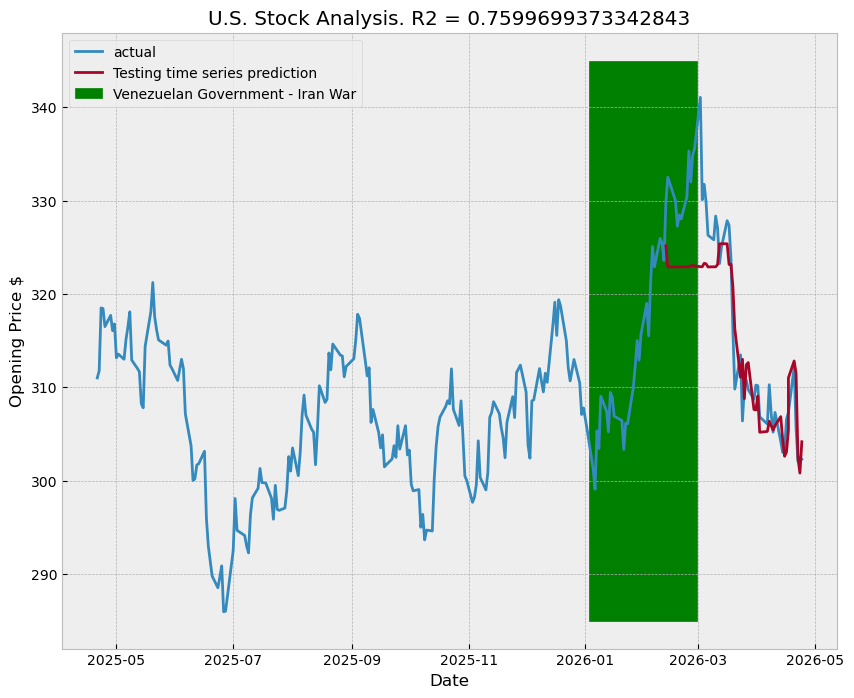

In [1222]:
plt.figure(figsize=(10,8))

plt.plot(df.index, df.open)

plt.plot(pd.to_datetime(open_price.tail(51).index), grid_predictions)


plt.fill_between([pd.to_datetime('2026-01-03'), 
                  pd.to_datetime('2026-02-28')], 285, 345, color='g')

plt.legend(['actual', 'Testing time series prediction', "Venezuelan Government - Iran War"])
plt.xlabel("Date") 
plt.ylabel("Opening Price $")
plt.title(f"U.S. Stock Analysis. R2 = {r2_score(y_true=Y_test, y_pred=grid_predictions)}")
plt.show()

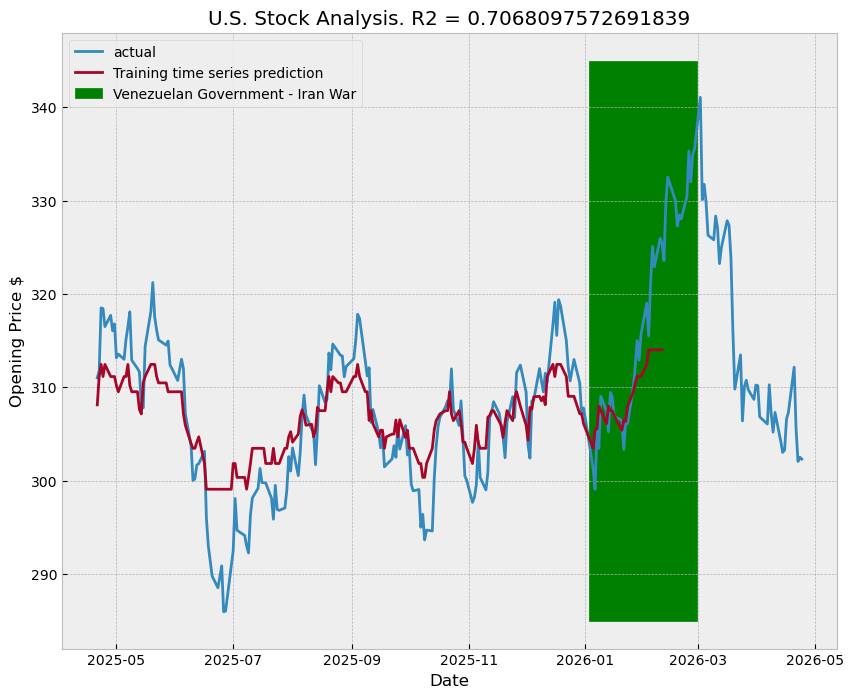

In [1224]:
train_pred = grid_search.predict(X_train) 


plt.figure(figsize=(10,8))
plt.plot(df.index, df.open) 

plt.plot(df.head(204).index, train_pred)

plt.fill_between([pd.to_datetime('2026-01-03'), 
                  pd.to_datetime('2026-02-28')], 285, 345, color='g')

plt.legend(['actual', 'Training time series prediction', "Venezuelan Government - Iran War"])
plt.xlabel("Date") 
plt.ylabel("Opening Price $")
plt.title(f"U.S. Stock Analysis. R2 = {r2_score(y_true=Y_train, y_pred=train_pred)}")
plt.show()

In [1225]:
import shap

In [1233]:
X

,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
0,2669900,301.7516,311.28,305.12,22,4,2025,0.0
1,4200700,311.8778,320.00,311.19,23,4,2025,2.0
2,3210100,311.2913,319.90,314.79,24,4,2025,2.0
3,2479500,309.0823,318.89,313.53,25,4,2025,0.0
4,2282900,309.5906,321.78,315.03,28,4,2025,0.0
...,...,...,...,...,...,...,...,...
250,3225500,311.3600,312.54,307.20,20,4,2026,NaN
251,2395200,306.9400,312.53,305.95,21,4,2026,NaN
252,2708100,301.8400,306.15,300.97,22,4,2026,NaN
253,2845600,300.0700,302.91,299.83,23,4,2026,NaN


In [1226]:
X_test

,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
204,4553200,321.4145,325.20,320.81,12,2,2026,2.0
205,6499700,330.2352,333.38,320.15,13,2,2026,2.0
206,3587900,325.7602,335.67,326.53,17,2,2026,2.0
207,3367200,325.8000,332.08,325.00,18,2,2026,2.0
208,3661800,326.0685,328.80,323.83,19,2,2026,2.0
209,4032300,325.2928,333.00,326.95,20,2,2026,2.0
210,3862700,327.4011,330.28,325.96,23,2,2026,2.0
211,3806200,332.7014,335.58,330.25,24,2,2026,2.0
212,2756900,331.1998,336.00,332.33,25,2,2026,2.0
213,2812500,331.1601,334.15,330.00,26,2,2026,2.0


In [1227]:
explainer = shap.TreeExplainer(grid_search.best_estimator_) 
shap_values = explainer(X_test)

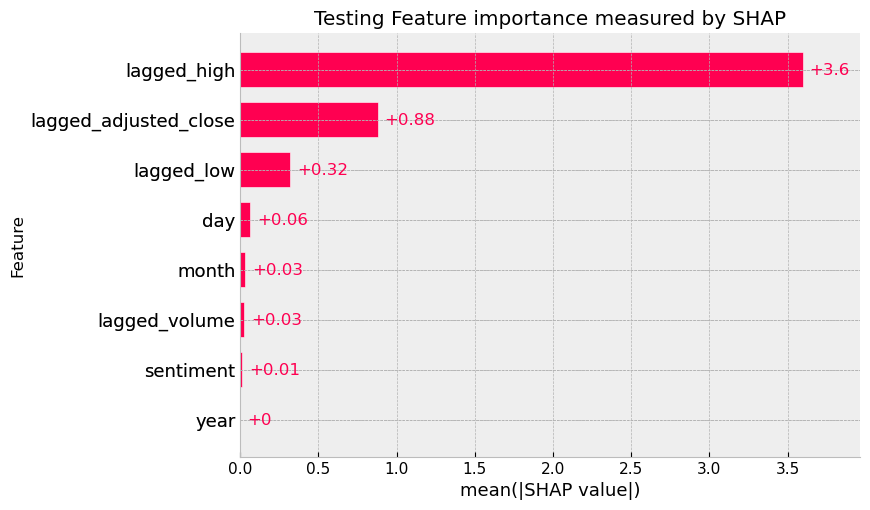

In [1228]:
shap.plots.bar(shap_values, show=False) 

plt.title("Testing Feature importance measured by SHAP")

plt.ylabel("Feature") 
plt.show()

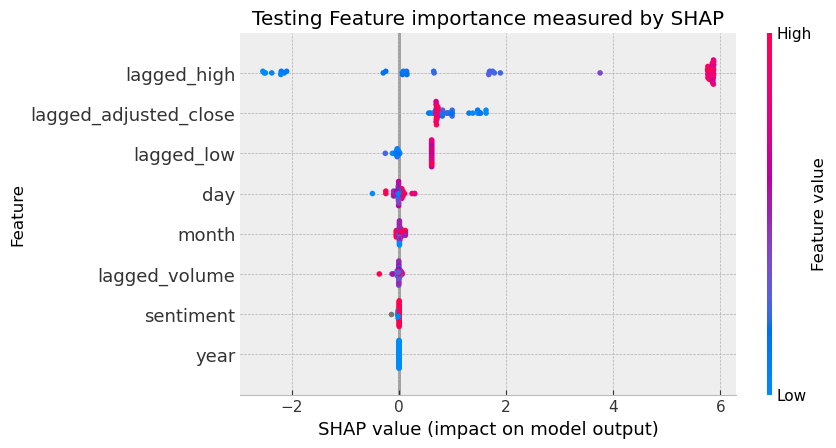

In [1229]:
shap.plots.beeswarm(shap_values, show=False) 
plt.title("Testing Feature importance measured by SHAP")
plt.ylabel("Feature") 
plt.show()

In [1230]:
# training data

train_shap_values = explainer(X_train)

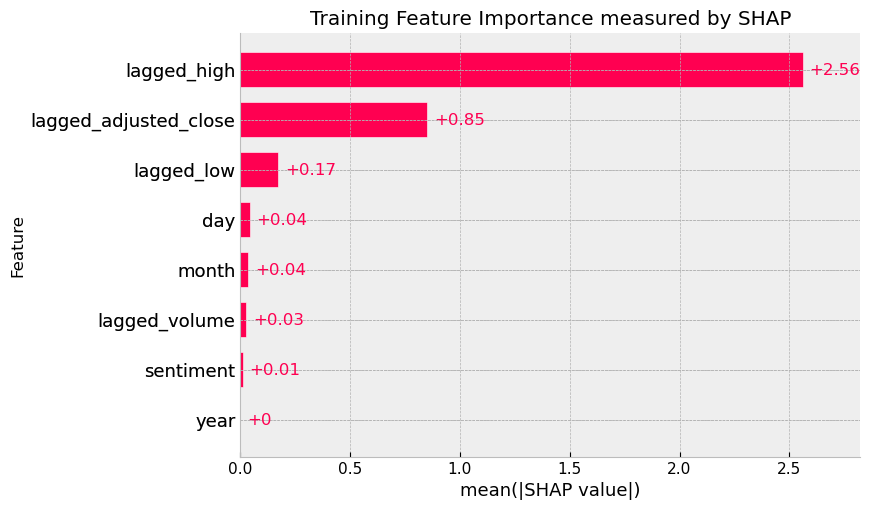

In [1231]:
shap.plots.bar(train_shap_values,show=False) 

plt.title("Training Feature Importance measured by SHAP")
plt.ylabel("Feature") 
plt.show()

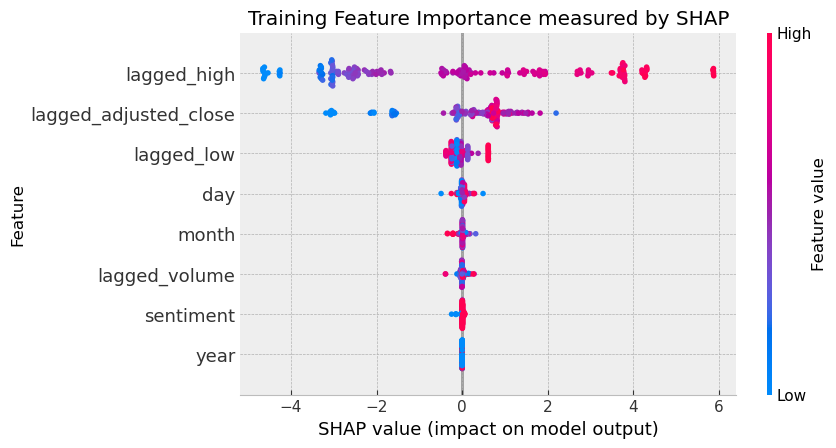

In [1232]:
shap.plots.beeswarm(train_shap_values,show=False) 

plt.title("Training Feature Importance measured by SHAP")
plt.ylabel("Feature") 
plt.show()

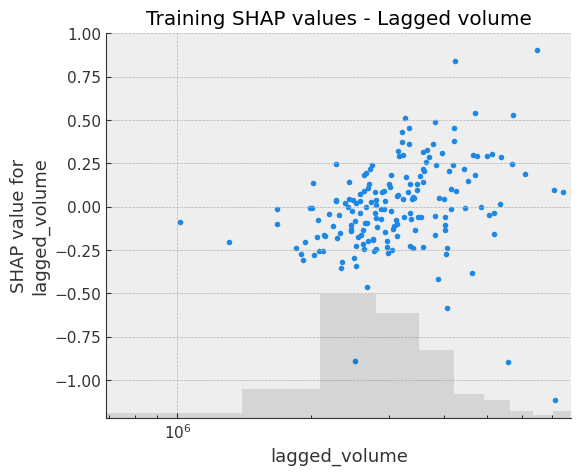

In [937]:
# looking at lagged volume 
shap.plots.scatter(train_shap_values[:, "lagged_volume"], show=False) 
plt.title("Training SHAP values - Lagged volume")
plt.xscale("log")
plt.show()



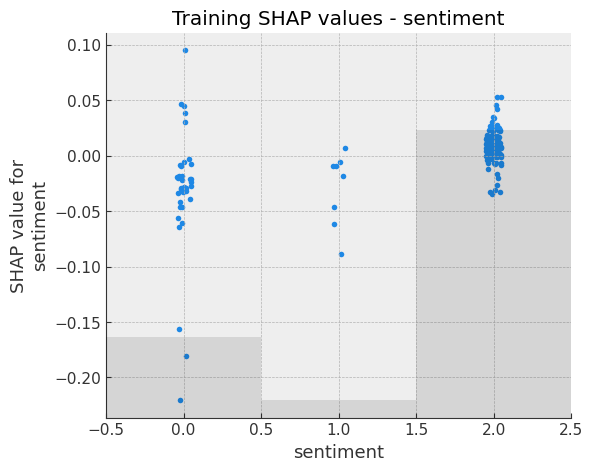

In [939]:
# looking at lagged volume 
shap.plots.scatter(train_shap_values[:, "sentiment"], show=False) 
plt.title("Training SHAP values - sentiment")

plt.show()



In [831]:
open_price

,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
date,,,,,,,,,,,,,
2025-04-22,311.76,4200700,320.00,311.19,311.8778,2669900,301.7516,311.28,305.12,22,4,2025,0
2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19,23,4,2025,1
2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79,24,4,2025,2
2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53,25,4,2025,0
2025-04-28,317.70,2578300,318.02,314.25,309.6590,2282900,309.5906,321.78,315.03,28,4,2025,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-16,306.58,2334400,308.27,304.57,306.9600,2976500,306.2600,306.94,303.00,16,4,2026,2
2026-04-17,307.31,2262412,312.53,307.20,311.3600,2334400,306.9600,308.27,304.57,17,4,2026,2
2026-04-17,307.31,3225500,312.54,307.20,311.3600,2262412,311.3600,312.53,307.20,17,4,2026,2


In [915]:
# marking market changes whenever there was negative news


open_price.rename({"sentiment_x": "sentiment"}, axis=1, inplace=True)

In [917]:
open_price

,open,volume,high,low,adjusted_close,lagged_volume,lagged_adjusted_close,lagged_high,lagged_low,day,month,year,sentiment
date,,,,,,,,,,,,,
2025-04-22,311.76,4200700,320.00,311.19,311.8778,2669900,301.7516,311.28,305.12,22,4,2025,0
2025-04-23,318.50,3210100,319.90,314.79,311.2913,4200700,311.8778,320.00,311.19,23,4,2025,1
2025-04-24,318.43,2479500,318.89,313.53,309.0823,3210100,311.2913,319.90,314.79,24,4,2025,2
2025-04-25,316.50,2282900,321.78,315.03,309.5906,2479500,309.0823,318.89,313.53,25,4,2025,0
2025-04-28,317.70,2578300,318.02,314.25,309.6590,2282900,309.5906,321.78,315.03,28,4,2025,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-16,306.58,2334400,308.27,304.57,306.9600,2976500,306.2600,306.94,303.00,16,4,2026,2
2026-04-17,307.31,2262412,312.53,307.20,311.3600,2334400,306.9600,308.27,304.57,17,4,2026,2
2026-04-17,307.31,3225500,312.54,307.20,311.3600,2262412,311.3600,312.53,307.20,17,4,2026,2
